Aluna:
- Maria Eduarda Neves
- meen@cin.ufpe.br

#Projeto de Visão Computacional

##Descrição do problema a ser resolvido

- O projeto tem como finalizade desenvolver um modelo de aprendizagem de máquina cujo objetivo é realizar classificação de imagens satélite do tipo RGB.
- As imagens foram coletadas através de um [Link do Kaggle](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset/data) que contém um conjunto de 27.000 imagens satélites, EuroSat Dataset,com um GSD de 10m, coletadas pelo Satélite Snetinel-2

- Descrição do banco de dados:
  - Dimensoes das imagens: 64x64 pixels com canais RGB;
  - Numero de classes: 10 classes de cobertura e uso do
  solo;
  - Tamanho do conjunto de dados: 27.000 imagens:
    - Treinamento: Cerca de 19.000 imagens;
    - Validação/Teste: Cerca de 8.000 imagens.

###Carregamento das bibliotecas que serão utilizadas no projeto

- Nesta etapa são carregadas as bibliotecas que serão utilizadas ao longo do projeto

In [1]:
# import torch
import pandas as pd
import random
import json
import os
import requests
import numpy as np
from tqdm import tqdm
import cv2
import matplotlib.image as mpimg
from sklearn.metrics import classification_report,top_k_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from PIL import Image
from collections import Counter
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from torchsummary import summary
from torch import nn, optim

import torch
from torchvision import transforms, datasets, models
from torch.utils import data
from torchvision.io import read_image
# from scipy.misc import imread
from skimage import io

###Escolha do `Device` onde o código vai rodar (GPU x CPU)

- GPUs são dispositivos especializados em computação tensorial, sendo assim, caso esteja disponível, é importante trabalhar com ela no projeto e não utilizando CPU.
- A GPU vai fazer que códigos, que normalmente demoram mais a rodar na CPU sejam rodados com uma maior efetividade e rapidez


In [2]:
# Este código serve para escolher efetivamente qual o device a ser utilizado
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
print(device)

cuda


###Aplicação de SEED

- A aplicação abaixo tem como objetivo permitir que o código seja replicável

In [3]:
def set_seed(seed):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Leave as True to ensure determinism. Some operations may crash
    torch.use_deterministic_algorithms(False)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

##Descrição da Técnica escolhida para a Solução do problema

Para solucionar o problema em questão, este projeto optou por fragmentar a o desenvolvimento técnico em três partes:

1. Carregamento dos Dados
2. Pré-Processamento dos Dados
3. Modelagem do Modelo

Cada uma dessas três partes contém outros subtópicos, de forma a facilitar a compreensão do desenvolvimento do processo. Abaixo está uma explicação resumida das etapdas de cada uma das partes mencionadas anteriormente.

1. Etapas relacionadas ao Carregamento dos Dados:
  - Carregamento das Imagens e dos Metadados: De posse do link do github obtenção das imagens e dos metadados referentes ao problema de classificação de imagens de satélite
    - Carregamento das imagens: Que se encontram em formato `.jpg`
    - Carregamento dos Metadados: Que se encontram em formato `.csv` e `.json`
  - Análise inicial do conjunto de dados
    - Análise inicial da quantidade de classes existentes e quantitativo de imagens para cada uma delas.

2. Etapas relacionadas ao Pré-Processamento dos dados:
  - Separação das imagens em conjuntos de acordo com os metadados
  - Visualização e desafios referentes aos conjuntos de imagens
  - Criação do DataSet para Pytorch
  - Criação do DataLoader para Pytorch
  - Calculo da média e desvio padrão dos pixels para os diferentes conjuntos de imagens (treinamento, validação e teste)
  - Inicialização do DataLoader com a média e desvio padrão calculados
  - Obsevação das Imagens do Dataloader

3. Modelagem:
  - Criação do modelo CNN: Modelo que foi escolhido para fazer a classificação das imagens
  - Setar os hiperparâmetros e variáveis relevantes
  - Criação de processos para o treinamento do modelo
  - Treinamento do modelo

###Carregamento dos dados

####Carregamento das Imagens e dos Metadados

- O carregamento das imagens e dos metadados será feito através do github
- Em um repositório GitHub foram salvas todas as imagens e os metadadores referentes às imagens de satélite do projeto

In [4]:
#Clonagem do repositório do github que contém os dados
!git clone https://github.com/meduardaeneves/visao_computacional_projeto.git

Cloning into 'visao_computacional_projeto'...
remote: Enumerating objects: 27021, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 27021 (delta 0), reused 0 (delta 0), pack-reused 27017 (from 1)
Receiving objects: 100% (27021/27021), 85.93 MiB | 12.30 MiB/s, done.
Updating files: 100% (27004/27004), done.


#####Carregamento das Imagens

- Será utilizado o `os.walk` para acessar o diretório onde as imagens se encontram e conseguir salvá-las corretamente

In [5]:
diretorio_git = 'visao_computacional_projeto/EuroSAT'
classes_imagens = []
dict_imagens = {}
tamanho_imagens = []

for raiz,diretorio,arquivo in os.walk(diretorio_git):
  lista_imagens = []
  #esse raiz_name vai pegar o nome das pastas que contém as imagens, excluindo o nome raiz do repositório
  raiz_name = raiz.split(diretorio_git+'/')
  if len(raiz_name) > 1:
    classes_imagens.append(raiz_name[1])
    for imagem in arquivo:
      #esse código abaixo vai adicionar as imagens para uma lista de imagens
      lista_imagens.append(imagem)
      #vai ser coletado a url da imagem para que em seguida ela seja gerada e seu tamanho verificado
      url_image = raiz + '/' + imagem
      verificar_imagem = Image.open(url_image)
      tamanho_imagem = verificar_imagem.size
      if tamanho_imagem not in tamanho_imagens:
        tamanho_imagens.append(tamanho_imagem)
    #ao final, a lista de imagens vai ser salva no dicionário, cuja chave vai ser a pasta raiz
    dict_imagens[raiz_name[1]] = lista_imagens


In [6]:
print(f'Quantidade de classes de Imagens Satélite: {len(classes_imagens)}')
print(f'Tamanho das imagens encontradas: {tamanho_imagens}')
print(f'Classes de Imagens Satélite:')
for classe_img in classes_imagens:
  print(f' - {classe_img}')

Quantidade de classes de Imagens Satélite: 10
Tamanho das imagens encontradas: [(64, 64)]
Classes de Imagens Satélite:
 - Pasture
 - Residential
 - Industrial
 - SeaLake
 - HerbaceousVegetation
 - PermanentCrop
 - Highway
 - River
 - Forest
 - AnnualCrop


- Vai ser criado um dataFrame que analisa o quantitativo de cada uma das classes, tomando como base o somatório total das imagens e cada um dos diferentes conjuntos (trainamento, validação e teste)

In [7]:
df_classes = pd.DataFrame(columns=['ClassName','conjunto_total','treinamento','validacao','teste'])

In [8]:
#Adicionar as classes obtidas no item anterior ao dataframe
df_classes['ClassName'] = classes_imagens

In [9]:
df_classes

,ClassName,conjunto_total,treinamento,validacao,teste
0,Pasture,NaN,NaN,NaN,NaN
1,Residential,NaN,NaN,NaN,NaN
2,Industrial,NaN,NaN,NaN,NaN
3,SeaLake,NaN,NaN,NaN,NaN
4,HerbaceousVegetation,NaN,NaN,NaN,NaN
5,PermanentCrop,NaN,NaN,NaN,NaN
6,Highway,NaN,NaN,NaN,NaN
7,River,NaN,NaN,NaN,NaN
8,Forest,NaN,NaN,NaN,NaN
9,AnnualCrop,NaN,NaN,NaN,NaN


In [10]:
# O código abaixo realiza o somatório total de imagens para cada uma das classes
total_imagens = 0
for keys,value in dict_imagens.items():
  tamanho_dict = len(dict_imagens[keys])
  total_imagens += tamanho_dict
  print(f'Classe: {keys}; Quantidade de Imagens: {tamanho_dict}')
  df_classes.loc[df_classes['ClassName'] == keys,'conjunto_total'] = tamanho_dict
print(f'\nTotal Imagens: {total_imagens}')

Classe: Pasture; Quantidade de Imagens: 2000
Classe: Residential; Quantidade de Imagens: 3000
Classe: Industrial; Quantidade de Imagens: 2500
Classe: SeaLake; Quantidade de Imagens: 3000
Classe: HerbaceousVegetation; Quantidade de Imagens: 3000
Classe: PermanentCrop; Quantidade de Imagens: 2500
Classe: Highway; Quantidade de Imagens: 2500
Classe: River; Quantidade de Imagens: 2500
Classe: Forest; Quantidade de Imagens: 3000
Classe: AnnualCrop; Quantidade de Imagens: 3000

Total Imagens: 27000


#####Carregamento dos Metadados

- Primeiro passo, para o carregamento das imagens, é obter, através do github disponível, o link raw de arquivos `.csv` que vai identificar, através do nome da imagem, se ela se encontra dentro do conjunto de treinamento, validação e teste
- Ademais, é carregado também um link para um arquivo `.json`. Este arquivo relaciona o label de cada uma das imagens ao seu tipo

In [11]:
#Alocação do link RAW para um url
url_train_data = 'visao_computacional_projeto/EuroSAT/train.csv'
url_validation_data = 'visao_computacional_projeto/EuroSAT/validation.csv'
url_test_data = 'visao_computacional_projeto/EuroSAT/test.csv'
url_labelmap = 'visao_computacional_projeto/EuroSAT/label_map.json'

In [12]:
#salvamento dos arquivos .csv em dataframes
df_train = pd.read_csv(url_train_data)
df_validation = pd.read_csv(url_validation_data)
df_test = pd.read_csv(url_test_data)

- Verificação de valores Nulos nos DataFrames de treinamento, validação e teste

In [13]:
#analisando os dataframes para itentificação de valores nulos:
#o primeiro sum() é responsável por trazer valores nulos em cada coluna
#o segundo sum() é responsável por trazer valores nulos no total
train_null_amount = df_train.isnull().sum().sum()
validation_null_amount = df_validation.isnull().sum().sum()
test_null_amount = df_test.isnull().sum().sum()

In [14]:
print(f'Quantidade de valores nulos no DataFrame de Treinamento: {train_null_amount}')
print(f'Quantidade de valores nulos no DataFrame de Validação: {validation_null_amount}')
print(f'Quantidade de valores nulos no DataFrame de Treinamento: {test_null_amount}')

Quantidade de valores nulos no DataFrame de Treinamento: 0
Quantidade de valores nulos no DataFrame de Validação: 0
Quantidade de valores nulos no DataFrame de Treinamento: 0


- Verificação da dimensão dos dataframes e informações apresentadas neles:

In [15]:
print(f'Dimensão do DataFrame de Treinamento: {len(df_train)}')
print(f'Dimensão do DataFrame de Validação: {len(df_validation)}')
print(f'Dimensão do DataFrame de Teste: {len(df_test)}')

Dimensão do DataFrame de Treinamento: 18900
Dimensão do DataFrame de Validação: 5400
Dimensão do DataFrame de Teste: 2700


In [16]:
columns_train = df_train.columns
columns_validation = df_validation.columns
columns_test = df_test.columns

print(f'Colunas no DataFrame de Treinamento: {columns_train}')
print(f'Colunas no DataFrame de Validação: {columns_validation}')
print(f'Colunas no DataFrame de Teste: {columns_test}')

Colunas no DataFrame de Treinamento: Index(['Unnamed: 0', 'Filename', 'Label', 'ClassName'], dtype='object')
Colunas no DataFrame de Validação: Index(['Unnamed: 0', 'Filename', 'Label', 'ClassName'], dtype='object')
Colunas no DataFrame de Teste: Index(['Unnamed: 0', 'Filename', 'Label', 'ClassName'], dtype='object')


- Abaixo está a representação de um destes dataframe

In [17]:
df_train = df_train.set_index('Unnamed: 0')
df_validation = df_validation.set_index('Unnamed: 0')
df_test = df_test.set_index('Unnamed: 0')

In [18]:
df_train

,Filename,Label,ClassName
Unnamed: 0,,,
16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
2223,Industrial/Industrial_453.jpg,4,Industrial
4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation
...,...,...,...
4498,HerbaceousVegetation/HerbaceousVegetation_1952...,2,HerbaceousVegetation
1149,Pasture/Pasture_1252.jpg,5,Pasture
15489,AnnualCrop/AnnualCrop_2332.jpg,0,AnnualCrop


- Vamos tentar agora visualizar uma imagem qualquer do conjunto de treinamento, tomando como base o seu `Filename`

In [19]:
imagem_escolhida = df_train['Filename'][0]

url_image_teste = diretorio_git+'/'+imagem_escolhida
imagem_teste = Image.open(url_image_teste)

Referência da Imagem: Pasture/Pasture_1887.jpg - Conjunto de Treinamento
Tamanho da imagem escolhida: (64, 64)


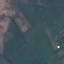

In [20]:
print(f'Referência da Imagem: {imagem_escolhida} - Conjunto de Treinamento')
print(f'Tamanho da imagem escolhida: {imagem_teste.size}')
imagem_teste

- Agora, será feito o carregamento do arquivo JSON que informa as diferentes classes existentes, em conjunto com as suas labels

In [21]:
with open(url_labelmap,'r') as file_labelmap:
  label_map = dict(json.load(file_labelmap))

In [22]:
print('Apresentação dos valores obtidos com o arquivo .json:')
for key,value in label_map.items():
  print(f'  - {key}: {value}')

Apresentação dos valores obtidos com o arquivo .json:
  - AnnualCrop: 0
  - Forest: 1
  - HerbaceousVegetation: 2
  - Highway: 3
  - Industrial: 4
  - Pasture: 5
  - PermanentCrop: 6
  - Residential: 7
  - River: 8
  - SeaLake: 9


In [23]:
# Serão criadas listas para as chaves e seus respectivos valores
label_map_keys = list(label_map.keys())
label_map_values = list(label_map.values())

#Por fim, será criado um dataframe, onde os nome das colunas será o mesmo identificado nos arquivos .csv
label_map_df = pd.DataFrame({'ClassName': label_map_keys, 'Label': label_map_values})

In [24]:
label_map_df

,ClassName,Label
0,AnnualCrop,0
1,Forest,1
2,HerbaceousVegetation,2
3,Highway,3
4,Industrial,4
5,Pasture,5
6,PermanentCrop,6
7,Residential,7
8,River,8
9,SeaLake,9


In [25]:
df_classes = pd.merge(df_classes, label_map_df, on='ClassName', how='left')

In [26]:
nova_ordem = ['ClassName','Label','conjunto_total','treinamento','validacao','teste']
df_classes = df_classes[nova_ordem].sort_values(by=['Label'])

In [27]:
df_classes

,ClassName,Label,conjunto_total,treinamento,validacao,teste
9,AnnualCrop,0,3000,NaN,NaN,NaN
8,Forest,1,3000,NaN,NaN,NaN
4,HerbaceousVegetation,2,3000,NaN,NaN,NaN
6,Highway,3,2500,NaN,NaN,NaN
2,Industrial,4,2500,NaN,NaN,NaN
0,Pasture,5,2000,NaN,NaN,NaN
5,PermanentCrop,6,2500,NaN,NaN,NaN
1,Residential,7,3000,NaN,NaN,NaN
7,River,8,2500,NaN,NaN,NaN
3,SeaLake,9,3000,NaN,NaN,NaN


- Podemos analisar para cada conjunto de treinamento, validação e teste a quantidade de cada elemento que existe:

In [28]:
dif_labels_train = df_train['Label'].value_counts().sort_index(ascending=True).reset_index()
dif_labels_validation = df_validation['Label'].value_counts().sort_index(ascending=True).reset_index()
dif_labels_test = df_test['Label'].value_counts().sort_index(ascending=True).reset_index()

In [29]:
qnt_train_list = []
qnt_validation_list = []
qnt_test_list = []

print('Quantitativo de cada classe nos diferentes conjuntos: ')
for i, value in enumerate(df_classes['Label']):
  qnt_train = dif_labels_train['count'][i]
  qnt_validation = dif_labels_validation['count'][i]
  qnt_test = dif_labels_test['count'][i]

  qnt_train_list.append(qnt_train)
  qnt_validation_list.append(qnt_validation)
  qnt_test_list.append(qnt_test)

  print(f"Classe: {value}: Qnt treinamento: {qnt_train}; Qnt Validação: {qnt_validation}; Qnt Teste: {qnt_test}")

Quantitativo de cada classe nos diferentes conjuntos: 
Classe: 0: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 1: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 2: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 3: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 4: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 5: Qnt treinamento: 1400; Qnt Validação: 400; Qnt Teste: 200
Classe: 6: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 7: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 8: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 9: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300


In [30]:
df_classes['treinamento'] = qnt_train_list
df_classes['validacao'] = qnt_validation_list
df_classes['teste'] = qnt_test_list

####Análise Inicial do conjunto de dados

Através de gráficos é possível observar o quantitativo geral de cada uma das imagens e ver como de da a distribuição delas através dos diferentes conjunto de treinamento, validação e teste

In [31]:
df_classes

,ClassName,Label,conjunto_total,treinamento,validacao,teste
9,AnnualCrop,0,3000,2100,600,300
8,Forest,1,3000,2100,600,300
4,HerbaceousVegetation,2,3000,2100,600,300
6,Highway,3,2500,1750,500,250
2,Industrial,4,2500,1750,500,250
0,Pasture,5,2000,1400,400,200
5,PermanentCrop,6,2500,1750,500,250
1,Residential,7,3000,2100,600,300
7,River,8,2500,1750,500,250
3,SeaLake,9,3000,2100,600,300


In [32]:
colors = ['lightcoral','lightblue','mediumpurple','lightpink',
          'lightseagreen','goldenrod','lightgreen','lightsalmon',
          'lightslategrey','sandybrown']

In [33]:
new_class_name = []
for i in range(len(df_classes)):
  new_class_name.append(f'{df_classes["Label"][i]}: {df_classes["ClassName"][i]}')

In [34]:
new_class_name.sort()

In [35]:
print(new_class_name)

['0: AnnualCrop', '1: Forest', '2: HerbaceousVegetation', '3: Highway', '4: Industrial', '5: Pasture', '6: PermanentCrop', '7: Residential', '8: River', '9: SeaLake']


In [36]:
fig = go.Figure(
    data=[
        go.Bar(
            x=df_classes['ClassName'],
            y=df_classes['conjunto_total'],
            marker=dict(color=colors[:len(df_classes)]),
            showlegend=False,
        ),
        go.Scatter(
            x=df_classes['ClassName'],
            y=df_classes['treinamento'],
            name = 'Conjunto de Treinamento',
            line=dict(color='purple', width=1),
        ),
        go.Scatter(
            x=df_classes['ClassName'],
            y=df_classes['validacao'],
            name = 'Conjunto de Validação',
            line=dict(color='red', width=1),
        ),
        go.Scatter(
            x=df_classes['ClassName'],
            y=df_classes['teste'],
            name = 'Conjunto de Teste',
            line=dict(color='blue', width=1),
        ),
    ]
)

fig.update_layout(
    title="Distribuição dos Conjuntos de Dados por Classe",
    xaxis_title="Classe",
    yaxis_title="Quantidade de Imagens",
    xaxis=dict(
        tickvals=df_classes['ClassName'],  # Valores no eixo x
        ticktext=new_class_name  # Novos rótulos para o eixo x
    )
)

fig.show()

- Observando o gráfico apresentado pode-se observar um desbalanceamento entre as diferentes classes presentes no dataset. Este problema pode vir a influenciar na hora da classificação, onde as classes que apresentam uma menor quantidade de amostras tem mais dificuldade de serem identificadas corretamente.
- Sendo assim, deve-se, ao final do projeto, observar se de fato as classes que apresentaram uma menor quantidade de amostras foram desfavorecidas. São elas:
  - Classe 5 (Pasture): 2000 imagens totais;
  - Classes 3,4,6 e 8 (Highway, Industrial, PermanentCrop, River, respectivamente): 2500 imagens totais

###Pré-Processamento dos dados

- O pré-processamento dos dados tem como objetivo deixar as imagens prontas para que elas possam ser efetivamente usadas no treinamento do modelo

#####Separação das imagens em conjuntos de acordo com os metadados

In [37]:
def criacao_lista_imagem2(df_metadado):
  lista_imagem = []
  label_imagem = []
  for i in range(len(df_metadado)):
    name_imagem = df_metadado['Filename'][i]
    label = df_metadado['Label'][i]

    url_image = diretorio_git+'/'+name_imagem
    imagem = io.imread(url_image)
    # imagem = read_image(url_image)
    # # imagem = imagem.float()/255
    # # imagem = Image.open(url_image)

    lista_imagem.append(imagem)
    label_imagem.append(label)
  return lista_imagem, label_imagem

In [38]:
def criacao_lista_imagem(df_metadado,tipo_transform):
  lista_imagem = []
  label_imagem = []
  for i in range(len(df_metadado)):
    name_imagem = df_metadado['Filename'][i]
    label = df_metadado['Label'][i]
    # print(label, name_imagem)

    url_image = diretorio_git+'/'+name_imagem
    # imagem = io.imread(url_image)
    # imagem = read_image(url_image)
    # imagem = imagem.float()/255

    if tipo_transform == "Image":
      #retorna imagem do tipo "Image" usando biblioteca PIL
      imagem = Image.open(url_image)
    elif tipo_transform == 'opencv':
      #retorna uma matriz do tipo NumPy
      imagem = cv2.imread(url_image)

    lista_imagem.append(imagem)
    label_imagem.append(label)
  return lista_imagem, label_imagem

In [39]:
x_train_image, y_train_image = criacao_lista_imagem(df_train, 'Image')
x_validation_image, y_validation_image = criacao_lista_imagem(df_validation,'Image')
x_test_image, y_test_image = criacao_lista_imagem(df_test,'Image')

x_train_cv, y_train_cv = criacao_lista_imagem(df_train, 'opencv')
x_validation_cv, y_validation_cv = criacao_lista_imagem(df_validation,'opencv')
x_test_cv, y_test_cv = criacao_lista_imagem(df_test,'opencv')

In [40]:
print(f'Quantidade de imagens de treinamento: {len(x_train_image)}; Qnt labels: {len(y_train_image)}')
print(f'Quantidade de imagens de validação: {len(x_validation_image)}; Qnt labels: {len(y_validation_image)}')
print(f'Quantidade de imagens de teste: {len(x_test_image)}; Qnt labels: {len(y_test_image)}')

Quantidade de imagens de treinamento: 18900; Qnt labels: 18900
Quantidade de imagens de validação: 5400; Qnt labels: 5400
Quantidade de imagens de teste: 2700; Qnt labels: 2700


- Com isso, é possível validar que os conjuntos separados estão com o mesmo tamanho de cada um dos metadados baixados

- Em seguinta, será feita a análise para observar se cada classe, depois dessa separação dos dados, também está com o mesmo quantitativo observado anteriormente.

In [41]:
contagem_train = Counter(y_train_image)
contagem_validation = Counter(y_validation_image)
contagem_test = Counter(y_test_image)

for i in label_map_values:
  print(f"Classe: {i}: Qnt treinamento: {contagem_train[i]}; Qnt Validação: {contagem_validation[i]}; Qnt Teste: {contagem_test[i]}")

Classe: 0: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 1: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 2: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 3: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 4: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 5: Qnt treinamento: 1400; Qnt Validação: 400; Qnt Teste: 200
Classe: 6: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 7: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300
Classe: 8: Qnt treinamento: 1750; Qnt Validação: 500; Qnt Teste: 250
Classe: 9: Qnt treinamento: 2100; Qnt Validação: 600; Qnt Teste: 300


In [42]:
print('Tipo do conteúdo da lista de imagem, versão 01, usando <Image.open(url_image)>:')
print(type(x_train_image[0]))
print(f' - Exemplo: \n {x_train_image[0]}')

print('\nTipo do conteúdo da lista de imagem, versão 02, usando <cv2.imread(url_image)>:')
print(type(x_train_cv[0]))
print(f' - Exemplo: \n {x_train_cv[0]}')

Tipo do conteúdo da lista de imagem, versão 01, usando <Image.open(url_image)>:
<class 'PIL.JpegImagePlugin.JpegImageFile'>
 - Exemplo: 
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64 at 0x7980A611E890>

Tipo do conteúdo da lista de imagem, versão 02, usando <cv2.imread(url_image)>:
<class 'numpy.ndarray'>
 - Exemplo: 
 [[[124 126 150]
  [124 127 148]
  [122 123 144]
  ...
  [ 84  78  55]
  [ 84  80  56]
  [ 83  79  55]]

 [[127 127 151]
  [126 127 148]
  [122 123 144]
  ...
  [ 84  78  55]
  [ 84  80  56]
  [ 83  79  55]]

 [[122 120 142]
  [119 120 141]
  [124 125 146]
  ...
  [ 84  77  57]
  [ 85  79  56]
  [ 85  79  56]]

 ...

 [[ 92  87  66]
  [ 91  88  67]
  [ 92  89  68]
  ...
  [ 90  87  66]
  [ 94  92  74]
  [ 96  94  76]]

 [[ 92  90  66]
  [ 90  90  66]
  [ 90  89  68]
  ...
  [ 89  87  63]
  [ 95  91  72]
  [ 94  90  71]]

 [[ 90  90  66]
  [ 90  90  66]
  [ 90  89  68]
  ...
  [ 88  86  62]
  [ 94  91  70]
  [ 94  90  71]]]


- Lista de Imagens Versão 01:
  - Confirma-se que as imagens são RGB, 3 canais, e possuem tamanho 64x64 pixels.
- Lista de Imagens Versão 02:
  - Importante observar que os pixels da imagem convertida do tipo NumPy está no intervalo 0 - 255, isso precisa ser alterado no futuro para facilitar normalização.

#####Visualização e desafios referentes aos conjuntos de imagens

- Apresentação de um mosaico com 8 imagens de cada classe para melhor compreender como as imagens são apresentadas

In [43]:
def mosaico_labels_img(list_img,list_labels,label_wanted,type):
  # for batch_idx, (inputs, labels) in enumerate(train_dl):
  qnt_amostras = 0  # Contador de amostras válidas
  fig = plt.figure(figsize=(16, 8))

  for index, img in enumerate(list_img):
    if list_labels[index] == label_wanted:  # Verifica se o valor do label é 0
      qnt_amostras += 1
      ax = fig.add_subplot(2, 4, qnt_amostras, xticks=[], yticks=[])
      img = list_img[index]
      ax.imshow(img)

      for key, value in label_map.items():
        if value == label_wanted:
          label_name = key

      ax.set_title(f'Label: {list_labels[index]} ({label_name})')

    if qnt_amostras == 8:  # Se já tiver 8 amostras, encerra o loop
      break
  name_mosaico = f'mosaico_{type}_{label_wanted}'
  plt.savefig(name_mosaico, bbox_inches='tight', pad_inches=0)  # Você pode ajustar o nome e o formato do arquivo
  plt.close(fig)

  return name_mosaico

In [44]:
def plotar_mosaicos(list_mosaico):
  fig, axes = plt.subplots(5, 2, figsize=(15, 20))

  # Itera sobre os mosaicos e exibe em cada posição da grade
  for i, ax in enumerate(axes.flat):
      img = mpimg.imread(list_mosaico[i])  # Carrega a imagem do mosaico
      ax.imshow(img)  # Exibe a imagem no subgráfico
      ax.axis('off')  # Remove os eixos
      # ax.set_title(f'Mosaico {i+1}')  # Título de cada mosaico

  plt.subplots_adjust(wspace=.05, hspace=0)

  # Exibe a figura com os mosaicos
  plt.show()

In [45]:
mosaico_train_original_0 = mosaico_labels_img(x_train_image, y_train_image,0,'train_original') + ".png"
mosaico_train_original_1 = mosaico_labels_img(x_train_image, y_train_image,1,'train_original') + ".png"
mosaico_train_original_2 = mosaico_labels_img(x_train_image, y_train_image,2,'train_original') + ".png"
mosaico_train_original_3 = mosaico_labels_img(x_train_image, y_train_image,3,'train_original') + ".png"
mosaico_train_original_4 = mosaico_labels_img(x_train_image, y_train_image,4,'train_original') + ".png"
mosaico_train_original_5 = mosaico_labels_img(x_train_image, y_train_image,5,'train_original') + ".png"
mosaico_train_original_6 = mosaico_labels_img(x_train_image, y_train_image,6,'train_original') + ".png"
mosaico_train_original_7 = mosaico_labels_img(x_train_image, y_train_image,7,'train_original') + ".png"
mosaico_train_original_8 = mosaico_labels_img(x_train_image, y_train_image,8,'train_original') + ".png"
mosaico_train_original_9 = mosaico_labels_img(x_train_image, y_train_image,9,'train_original') + ".png"

In [46]:
mosaico_list_train_original = [f'mosaico_train_original_{i}.png' for i in range(0,10)]

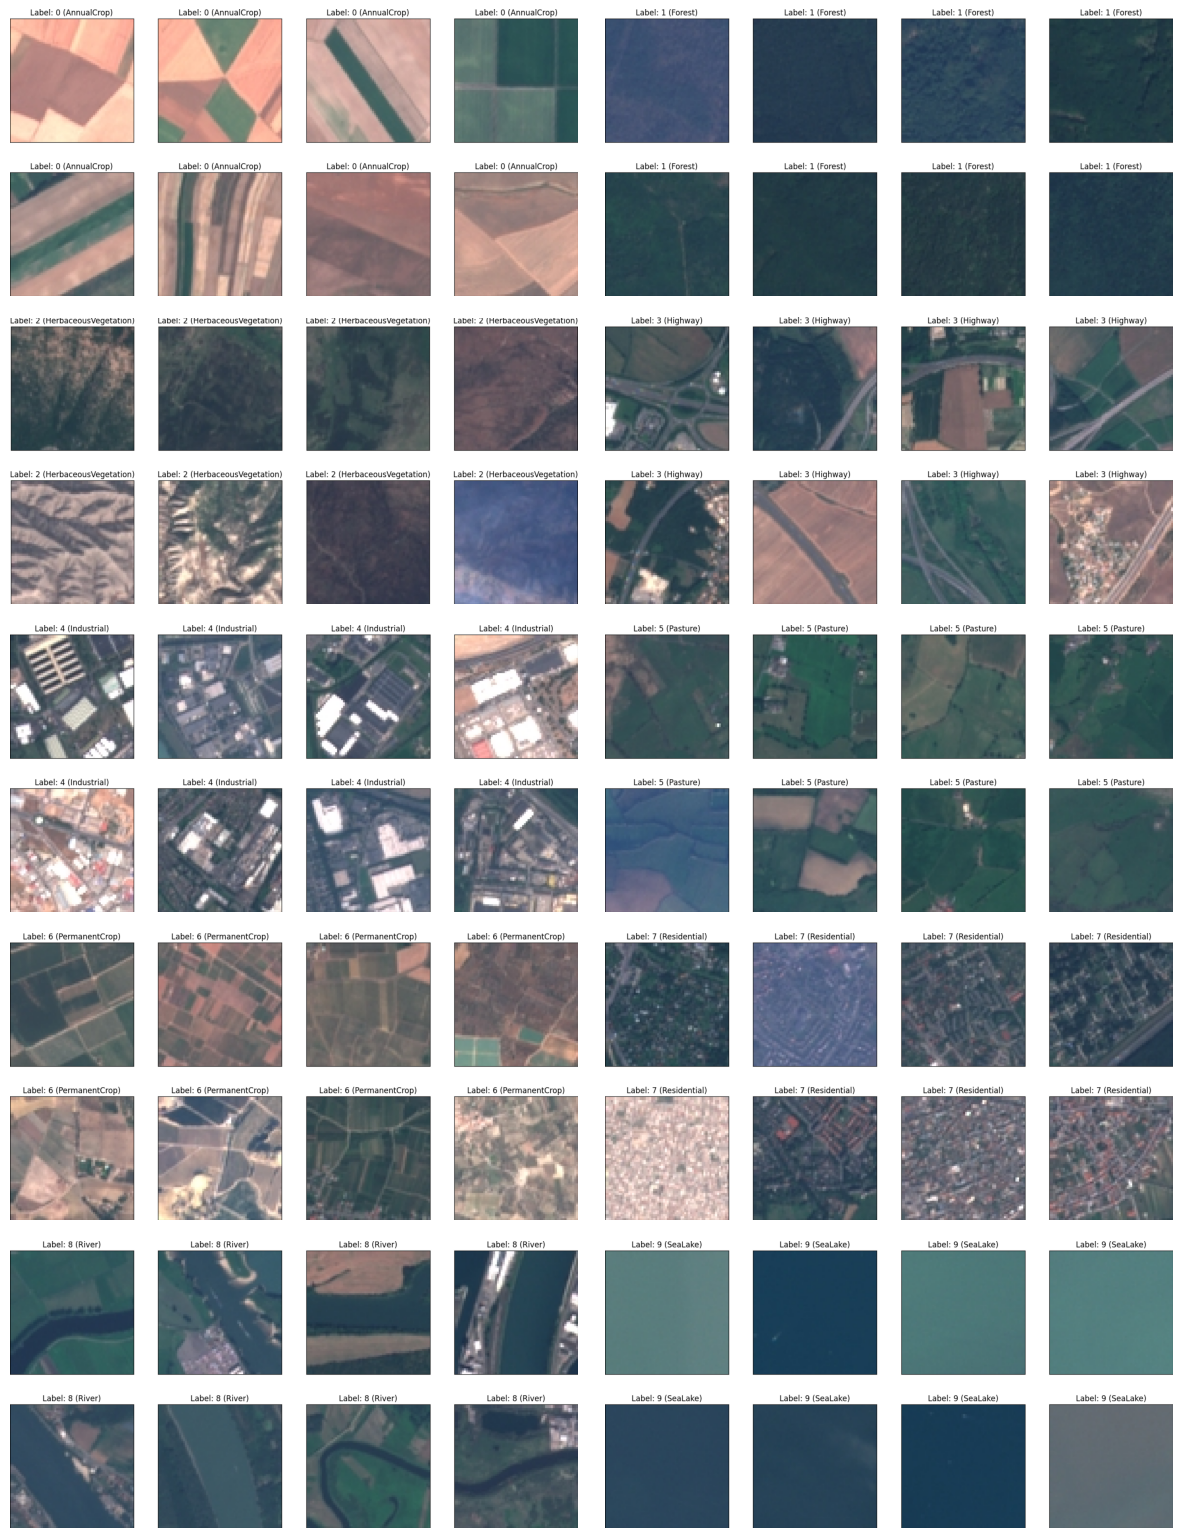

In [47]:
plotar_mosaicos(mosaico_list_train_original)

Considerações sobre as imagens apresentadas

- Resolução espacial limitada:
  - Como foi apresentado no início, as imagens possuem GSD de 10m. Isso significa que cada pixel da imagem representa uma área de 10m x 10m.
  - Esta característica indica que a imagem é de baixa resolução, podendo ser um problema no quesido de classificação, exigindo mais do modelo. Entretando, a baixa resolução permite que uma imagem conténha muita informação ao seu redor e isso pode ser um ponto positivo que ajude na sua classificação.
- Algumas imagens aparentam ser de baixa qualidade:
  - Principalmente as imagens de classe 1 (Forest), 2 (HerbaceousVegetation) e 9 (SeaLake):
    - Como elas não tem muitas informações ao seu redor, pode ser que as três venham a ser confundidas
  - As imagens tem um pouco baixas qualidades, as vezes tem imagens com núvens, etc
- Características que podem dificultar a generalização de padrões de cobertura do solo:
  - Devido à baixa resolução, as labels 3  e 8 podem vir a ser confundidas entre si, assim como as labels 4 e 7, isso devido a algumas similaridades que as imagens apresentam.

####Criação do DataSet para Pytorch

- É importante também criar uma classe, que neste caso será chamada de `EurosatDataset` para converter as listas de imagens e targets em um dataset válido para pytorch

In [48]:
#as imagens aqui já devem estar carregadas como lista de imagens devido à transformação
#feita anteriormente com "read_image(path)" função do pytorch
class EurosatDataset(data.Dataset):
  def __init__(self,images_list,label_list,transform=None,target_transform=None):
    self.images_list = images_list
    self.label_list = label_list
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.images_list)

  def __getitem__(self,idx):
    image = self.images_list[idx]
    label = self.label_list[idx]

    # image = image.float()/255

    if self.transform:
      # image = torch.tensor(image).float()/255
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(label)
    return image, label

- É feito um transform.Compose inicial, considerando que a imagem está na escala 0 - 255 a fim de descobrir, mais a frente, os reais valores para a normalização da imagem.

In [49]:
transform = transforms.Compose([
    transforms.ToTensor(),
#esse transforms vai escalar os pixels de [0-255] para [0-1]
    # transforms.Normalize((0,0,0),std=(1,1,1))
])

In [50]:
ds_inicial_train = EurosatDataset(
    x_train_cv,
    y_train_cv,
    transform=transform
)
ds_inicial_validation = EurosatDataset(
    x_validation_cv,
    y_validation_cv,
    transform=transform
)
ds_inicial_test = EurosatDataset(
    x_test_cv,
    y_test_cv,
    transform=transform
)

####Criação do Daloader para Pytorch

- Vai ser escolhido um valor aleatório para as batchs do dataloader.
  - Neste caso, foi escolhido 128, que é um múltiplo de 2 e permite pegar 128 amostras por batch

In [51]:
batch_size_init_train = 128
batch_size_init_validation = 128
batch_size_init_test = 128

In [52]:
dl_inicial_train = data.DataLoader(
    ds_inicial_train,
    batch_size=batch_size_init_train,
    shuffle=False, #Não embaralhar os dados a cada época
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)
dl_inicial_validation = data.DataLoader(
    ds_inicial_validation,
    batch_size=batch_size_init_validation,
    shuffle=False, #Não embaralhar os dados a cada época
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)
dl_inicial_test = data.DataLoader(
    ds_inicial_test,
    batch_size=batch_size_init_test,
    shuffle=False, #Não embaralhar os dados a cada época
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)

- Abaixo será apresentado como estão representados os inputs e as labels do dataloader:

In [53]:
for batch in dl_inicial_train:
    inputs, labels = batch
    print(inputs.shape, labels.shape)
    break

torch.Size([128, 3, 64, 64]) torch.Size([128])


- No código abaixo estão apresentadas algumas das imagens do conjunto de treinamento, depois da normalização inicial de 0 - 255, juntamente com o seu label

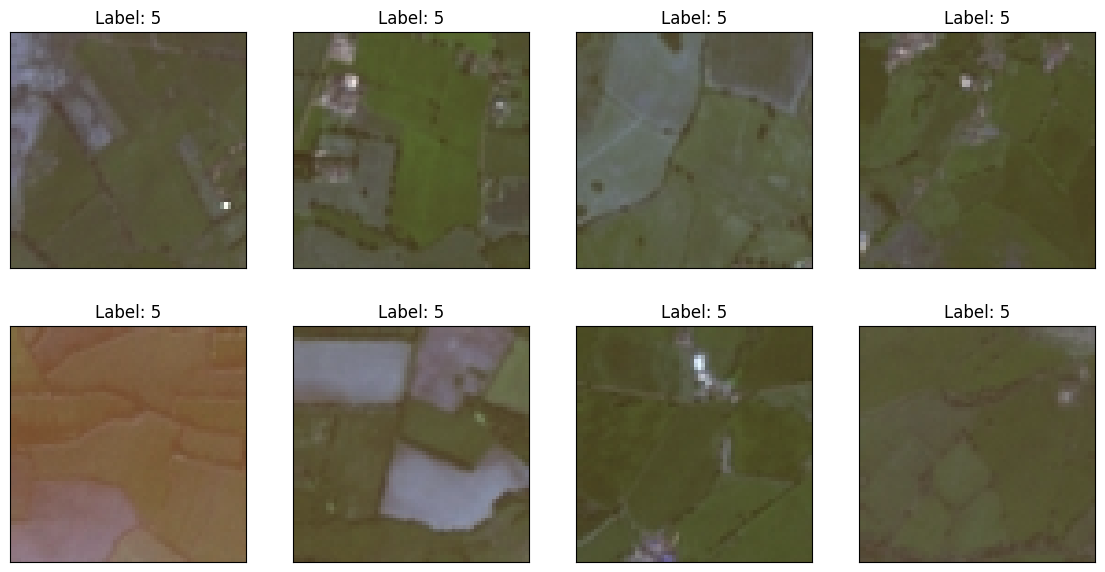

In [54]:
for batch_idx, (inputs,labels) in enumerate(dl_inicial_train):
    fig = plt.figure(figsize=(14, 7))
    for i in range(8):
        ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
        img = (inputs[i].numpy().transpose(1, 2, 0))
        ax.imshow(img)
        ax.set_title(f'Label: {labels[i].item()}')
    break

- Observa-se que o dataloader foi criado corretamente e que está funcionando bem. Sendo assim, pode-se partir para calcular os valores de média e desvio padrão que devem ser utilizados corretamente na normalização.

####Calculo da Média e Desvio Padrão dos Pixels para o conjunto de imagens

É necessário utilizar transforms para fazer a conversão das imagens para tensores. Entretando, para isso acontecer, é necessário calcular a média e o desvio padrão dos pixels a fim de normalizar as imagens:
  - A normalização vai ser uma padronização dos dados que utiliza uma média e um desvio padrão para controlar o range dos dados
  - Utiliza o Z-score para subtrair de uma dada imagem a média dos pixels e dividir pelo desvio padrão



In [55]:
#Essa função foi criada para, a partir do dataloader, calcular a média e o
#desvio padrão dos pixels
def calculo_media_despad_img(dataloader,original_list,img_height,img_width):
  media = torch.zeros(3)
  desv_pad = torch.zeros(3)

  pixels_total = len(original_list) * img_height * img_width

  for batch in tqdm(dataloader):
    inputs, labels = batch
    media += inputs.sum(axis=[0,2,3])
    desv_pad += (inputs**2).sum(axis=[0,2,3])

  total_media = media/pixels_total
  total_var = (desv_pad/pixels_total) - total_media**2
  total_desv_pad = torch.sqrt(total_var)


  return total_media, total_desv_pad

In [56]:
media_train, desvp_train = calculo_media_despad_img(dl_inicial_train,x_train_cv,64,64)
media_validation, desvp_validation = calculo_media_despad_img(dl_inicial_validation,x_validation_cv,64,64)
media_test, desvp_test = calculo_media_despad_img(dl_inicial_test,x_test_cv,64,64)

100%|██████████| 22/22 [00:00<00:00, 138.26it/s]


In [57]:
print(f'Imagens de Treinamento: media - {media_train}; desvio padrão - {desvp_train}')
print(f'Imagens de Validação: media - {media_validation}; desvio padrão - {desvp_validation}')
print(f'Imagens de Teste: media - {media_test}; desvio padrão - {desvp_test}')

Imagens de Treinamento: media - tensor([0.4078, 0.3803, 0.3445]); desvio padrão - tensor([0.1157, 0.1371, 0.2031])
Imagens de Validação: media - tensor([0.4069, 0.3793, 0.3433]); desvio padrão - tensor([0.1149, 0.1359, 0.2006])
Imagens de Teste: media - tensor([0.4093, 0.3818, 0.3457]); desvio padrão - tensor([0.1162, 0.1372, 0.2036])


####Inicialização do DataLoader com Média e Desvio Padrão calculados

É preciso recalcular o dataset, dessa vez levando em consideração os valores de normalização calculados corretamente.
- De inicio, o tensor de transformação foi calculado somente utilizando a transformação para tensor e a normalização das imagens, entretando, jugou-se necessário adicionar algumas características de DataAugmentation pois estava acontecendo overfitting no treinamento

In [58]:
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),  # Flip horizontal aleatório
    transforms.RandomRotation(20),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=media_train,std=desvp_train)
])
transform_validation = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),  # Flip horizontal aleatório
    transforms.RandomRotation(20),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=media_validation,std=desvp_validation)
])
transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),  # Flip horizontal aleatório
    transforms.RandomRotation(20),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=media_test,std=desvp_test)
])

In [59]:
ds_train = EurosatDataset(
    x_train_cv,
    y_train_cv,
    transform=transform_train
)
ds_validation = EurosatDataset(
    x_validation_cv,
    y_validation_cv,
    transform=transform_validation
)
ds_test = EurosatDataset(
    x_test_cv,
    y_test_cv,
    transform=transform_test
)

O dataloader vai receber os seguintes parâmetros:
- Dataset
- Batch Size: número de amostras por batch
  - O modelo foi treinado inicialmente com um batch size de 128, entretando, este valor não apresentou resultados satisfatórios e optou-se por aumentar para 256 a fim de ter mais amostras em cada batch de treinamento
- Suffle (True ou False): Se deseja que os dados sejam ou não embaralhados a cada época
- num_workers: cria subprocessos no carregamento dos dados
- pin_memory: acelera a memória do processo
- drop_last: False permite que o último batch tenha um tamanho menor



In [60]:
chosen_batch = 256

batch_size_train = chosen_batch
batch_size_validation = chosen_batch
batch_size_test = chosen_batch

In [61]:
train_dl = data.DataLoader(
    ds_train,
    batch_size=batch_size_train,
    shuffle=True, #Não embaralhar os dados a cada época
    # num_workers=2, #Criação de 2 subprocessos no carregamento dos dados
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)

validation_dl = data.DataLoader(
    ds_validation,
    batch_size=batch_size_validation,
    shuffle=True, #Não embaralhar os dados a cada época
    # num_workers=2, #Criação de 2 subprocessos no carregamento dos dados
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)

test_dl = data.DataLoader(
    ds_test,
    batch_size=batch_size_test,
    shuffle=True, #Não embaralhar os dados a cada época
    # num_workers=2, #Criação de 2 subprocessos no carregamento dos dados
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)

Visualizando as informações dos dataloaders:

In [62]:
inst_train, targ_train = next(iter(train_dl))
inst_validation, targ_validation = next(iter(validation_dl))
inst_test, targ_test = next(iter(test_dl))

print('Treinamento: ')
print(f'Instâncias [qnt de imagens batch, qnt de canais, altura img, largura img]: {inst_train.shape}')
print(f'Quantidade de Valores Target: {targ_train.shape}')
print(f'\nValidação: ')
print(f'Instâncias [qnt de imagens batch, qnt de canais, altura img, largura img]: {inst_validation.shape}')
print(f'Quantidade de Valores Target: {targ_validation.shape}')
print(f'\nTeste:')
print(f'Instâncias [qnt de imagens batch, qnt de canais, altura img, largura img]: {inst_test.shape}')
print(f'Quantidade de Valores Target: {targ_test.shape}')

Treinamento: 
Instâncias [qnt de imagens batch, qnt de canais, altura img, largura img]: torch.Size([256, 3, 64, 64])
Quantidade de Valores Target: torch.Size([256])

Validação: 
Instâncias [qnt de imagens batch, qnt de canais, altura img, largura img]: torch.Size([256, 3, 64, 64])
Quantidade de Valores Target: torch.Size([256])

Teste:
Instâncias [qnt de imagens batch, qnt de canais, altura img, largura img]: torch.Size([256, 3, 64, 64])
Quantidade de Valores Target: torch.Size([256])


#### Obsevação das Imagens do Dataloader

In [63]:
def mosaico_labels_img(train_dl,label_wanted,type):
  for batch_idx, (inputs, labels) in enumerate(train_dl):
      qnt_amostras = 0  # Contador de amostras válidas
      fig = plt.figure(figsize=(14, 7))

      # Verifica os labels e plota as imagens cujos labels são iguais a 0
      for i in range(len(labels)):  # Percorre todas as labels no batch
          if labels[i].item() == label_wanted:  # Verifica se o valor do label é 0
              qnt_amostras += 1
              ax = fig.add_subplot(2, 4, qnt_amostras, xticks=[], yticks=[])
              img = (inputs[i].numpy().transpose(1, 2, 0))
              ax.imshow(img)
              ax.set_title(f'Label: {labels[i].item()}')

          if qnt_amostras == 8:  # Se já tiver 8 amostras, encerra o loop
              break
      name_mosaico = f'mosaico_{type}_{label_wanted}'
      plt.savefig(name_mosaico, bbox_inches='tight', pad_inches=0)  # Você pode ajustar o nome e o formato do arquivo
      plt.close(fig)
      if qnt_amostras == 8:  # Encerra o loop de batches quando tiver 8 amostras
          break
  return name_mosaico


- O código abaixo apresenta os valores de tensores depois da normalização
  - Valores de tensores negativos vão estar relacionados à normalização dos dados. Que faz sentido, visto que usamos os valores de pixels para calculá-los, entretando, no caso de apresentação visual dessa imagens depois da normalização, podemos ter algumas variações visto que o representativo de imagem não está acostumado a receber valores negativos

- Tensor para o dataloader de treinamento como exemplo:

In [64]:
for images, labels in train_dl:
    pixels = images[0]  # Seleciona a primeira imagem do batch (C, H, W)
    print(f"Pixels da imagem (tensor): {pixels.shape}")
    print(f"Valores dos pixels: {pixels}")
    break

Pixels da imagem (tensor): torch.Size([3, 64, 64])
Valores dos pixels: tensor([[[-3.5259, -3.5259, -3.5259,  ..., -0.5422, -3.5259, -3.5259],
         [-3.5259, -3.5259, -3.5259,  ..., -0.6100, -3.5259, -3.5259],
         [ 0.8480,  0.6106,  0.1699,  ..., -0.5422, -3.5259, -3.5259],
         ...,
         [-3.5259, -3.5259, -0.6778,  ..., -0.3048, -0.2709, -0.3048],
         [-3.5259, -3.5259, -0.5422,  ..., -3.5259, -3.5259, -3.5259],
         [-3.5259, -3.5259, -0.4743,  ..., -3.5259, -3.5259, -3.5259]],

        [[-2.7738, -2.7738, -2.7738,  ..., -0.7719, -2.7738, -2.7738],
         [-2.7738, -2.7738, -2.7738,  ..., -0.8005, -2.7738, -2.7738],
         [ 0.8583,  0.7153,  0.2863,  ..., -0.8291, -2.7738, -2.7738],
         ...,
         [-2.7738, -2.7738, -0.7433,  ..., -0.2571, -0.2285, -0.2857],
         [-2.7738, -2.7738, -0.6289,  ..., -2.7738, -2.7738, -2.7738],
         [-2.7738, -2.7738, -0.5717,  ..., -2.7738, -2.7738, -2.7738]],

        [[-1.6961, -1.6961, -1.6961,  ..., -0

Abaixo são apresentados visualmente as imagens depois da normalização dos tensores e aplicações de transformações

- Conjunto de Treinamento

In [65]:
mosaico_train_0 = mosaico_labels_img(train_dl,0,'train') + ".png"
mosaico_train_1 = mosaico_labels_img(train_dl,1,'train') + ".png"
mosaico_train_2 = mosaico_labels_img(train_dl,2,'train') + ".png"
mosaico_train_3 = mosaico_labels_img(train_dl,3,'train') + ".png"
mosaico_train_4 = mosaico_labels_img(train_dl,4,'train') + ".png"
mosaico_train_5 = mosaico_labels_img(train_dl,5,'train') + ".png"
mosaico_train_6 = mosaico_labels_img(train_dl,6,'train') + ".png"
mosaico_train_7 = mosaico_labels_img(train_dl,7,'train') + ".png"
mosaico_train_8 = mosaico_labels_img(train_dl,8,'train') + ".png"
mosaico_train_9 = mosaico_labels_img(train_dl,9,'train') + ".png"

In [66]:
mosaico_list_train = [f'mosaico_train_{i}.png' for i in range(0,10)]

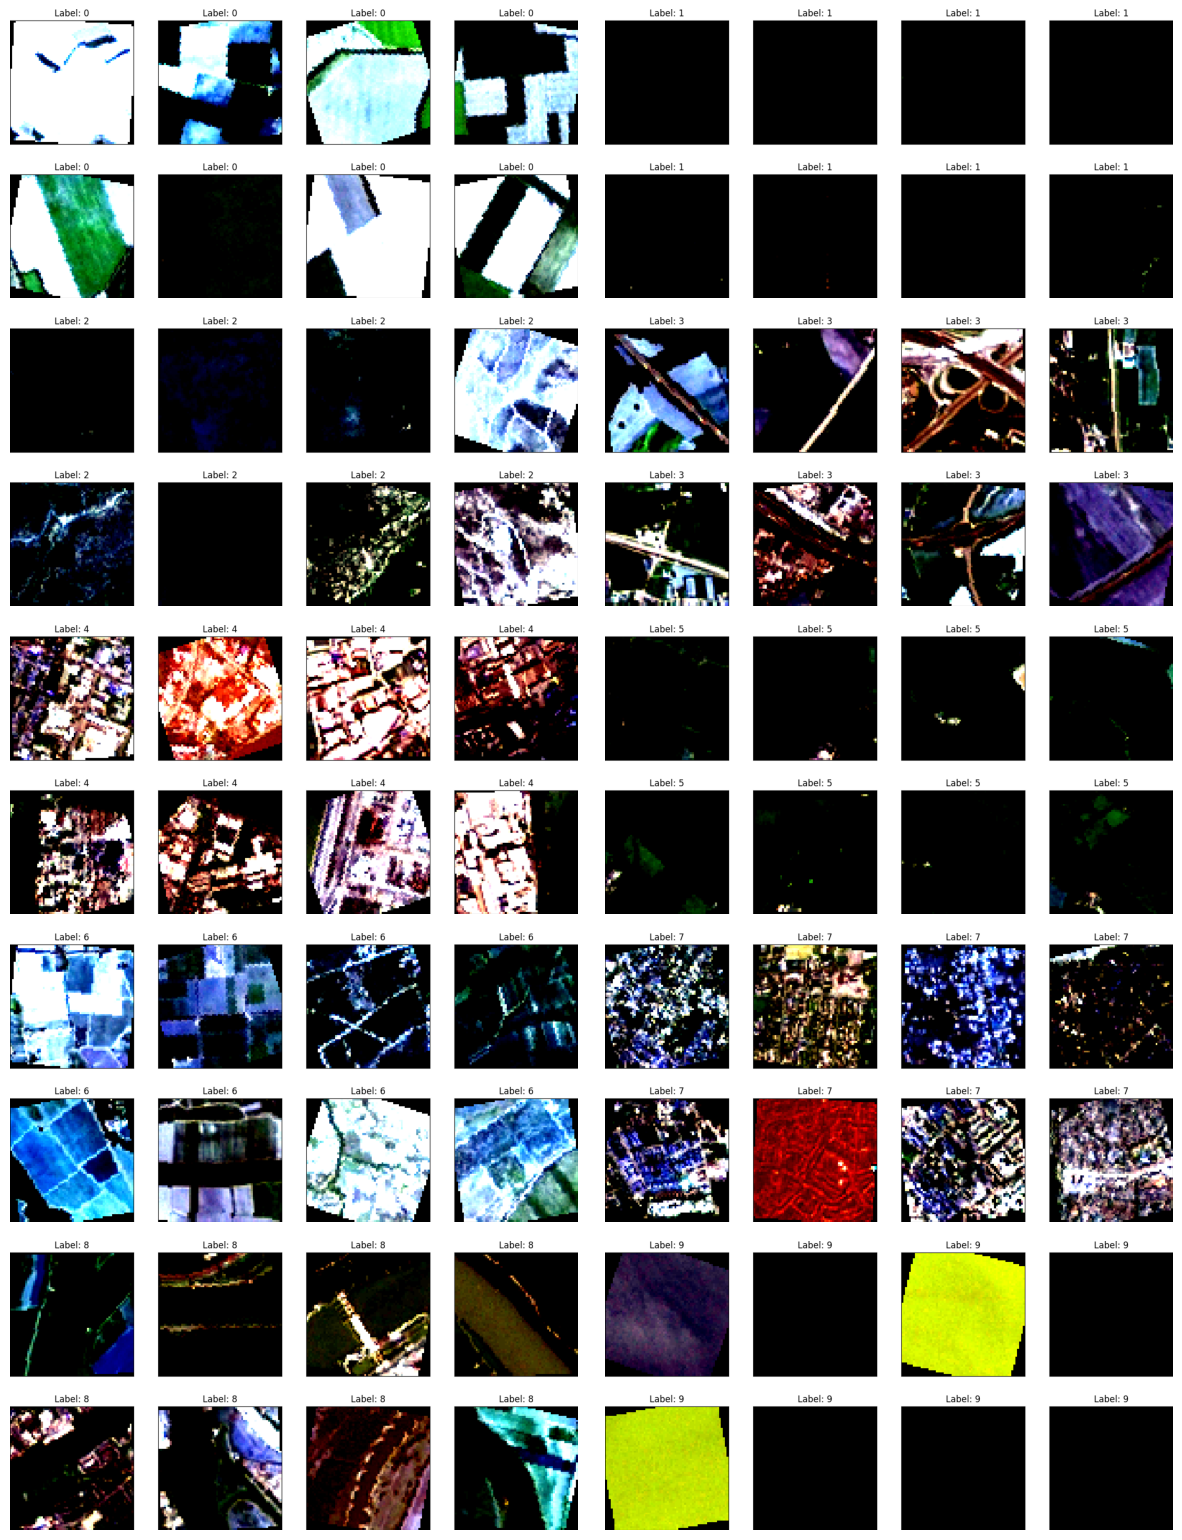

In [67]:
plotar_mosaicos(mosaico_list_train)

- Conjunto de Validação

In [68]:
mosaico_validation_0 = mosaico_labels_img(validation_dl,0,'validation') + ".png"
mosaico_validation_1 = mosaico_labels_img(validation_dl,1,'validation') + ".png"
mosaico_validation_2 = mosaico_labels_img(validation_dl,2,'validation') + ".png"
mosaico_validation_3 = mosaico_labels_img(validation_dl,3,'validation') + ".png"
mosaico_validation_4 = mosaico_labels_img(validation_dl,4,'validation') + ".png"
mosaico_validation_5 = mosaico_labels_img(validation_dl,5,'validation') + ".png"
mosaico_validation_6 = mosaico_labels_img(validation_dl,6,'validation') + ".png"
mosaico_validation_7 = mosaico_labels_img(validation_dl,7,'validation') + ".png"
mosaico_validation_8 = mosaico_labels_img(validation_dl,8,'validation') + ".png"
mosaico_validation_9 = mosaico_labels_img(validation_dl,9,'validation') + ".png"

In [69]:
mosaico_list_validation = [f'mosaico_validation_{i}.png' for i in range(0,10)]

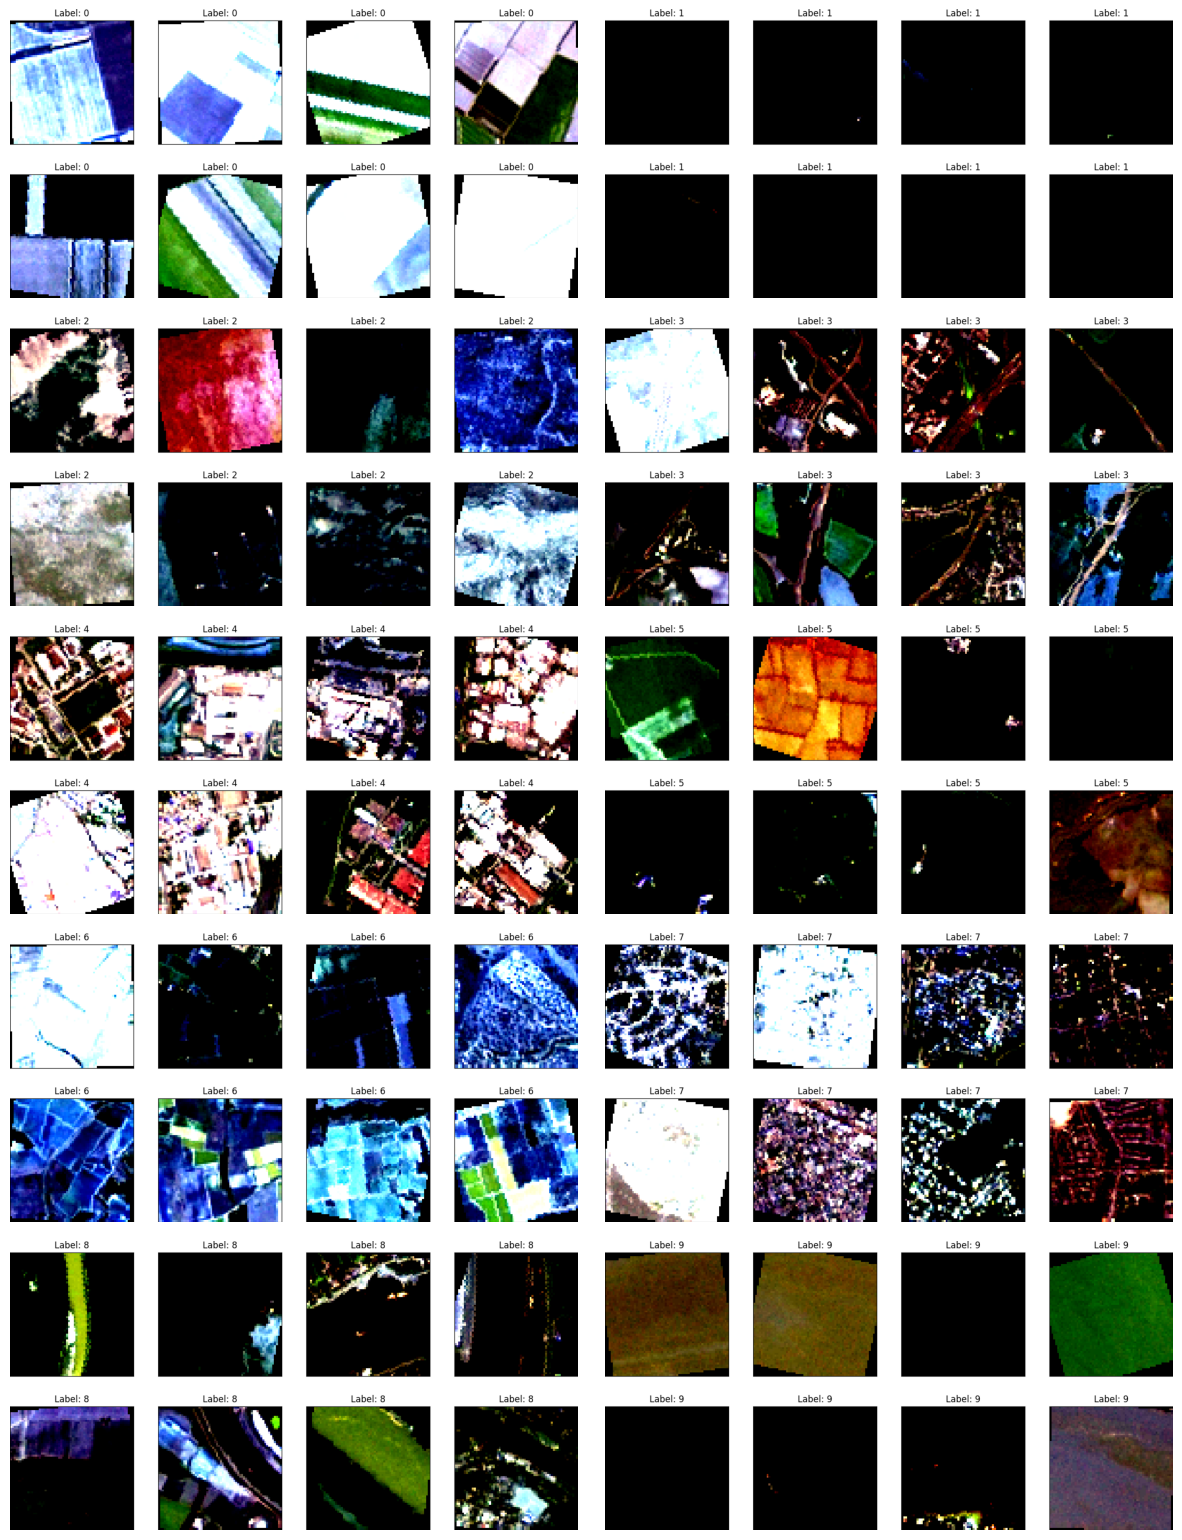

In [70]:
plotar_mosaicos(mosaico_list_validation)

- Conjunto de teste

In [71]:
mosaico_test_0 = mosaico_labels_img(test_dl,0,'test') + ".png"
mosaico_test_1 = mosaico_labels_img(test_dl,1,'test') + ".png"
mosaico_test_2 = mosaico_labels_img(test_dl,2,'test') + ".png"
mosaico_test_3 = mosaico_labels_img(test_dl,3,'test') + ".png"
mosaico_test_4 = mosaico_labels_img(test_dl,4,'test') + ".png"
mosaico_test_5 = mosaico_labels_img(test_dl,5,'test') + ".png"
mosaico_test_6 = mosaico_labels_img(test_dl,6,'test') + ".png"
mosaico_test_7 = mosaico_labels_img(test_dl,7,'test') + ".png"
mosaico_test_8 = mosaico_labels_img(test_dl,8,'test') + ".png"
mosaico_test_9 = mosaico_labels_img(test_dl,9,'test') + ".png"

In [72]:
mosaico_list_test = [f'mosaico_test_{i}.png' for i in range(0,10)]

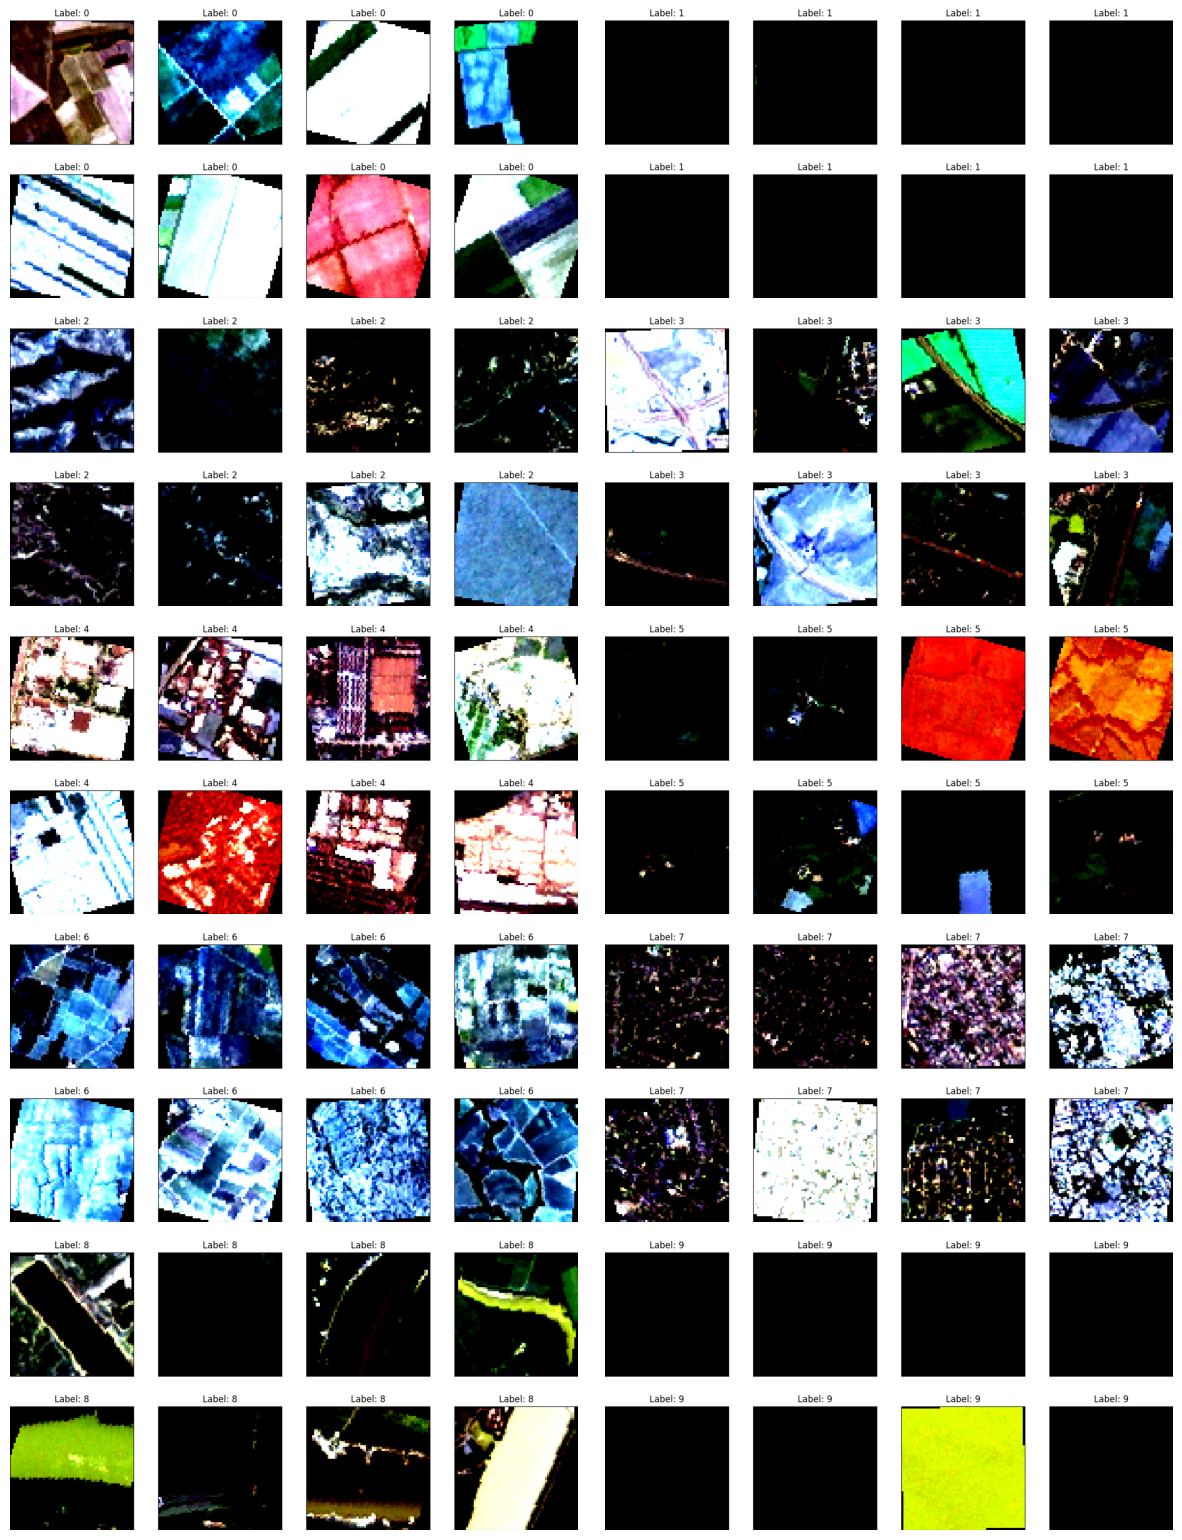

In [73]:
plotar_mosaicos(mosaico_list_test)

- Pode-se, através dessas imagens, concluir que a normalização foi aplicada corretamente nos dados.

###Modelagem

- Para a modelagem do modelo, optou-se por utilizar CNN (Convolutional Neural Network) um algorítmo de aprendizagem profunda muito utilizada em casos onde é importante reconhecer objetos, como é o caso da classificação de imagens
  - CNN são compostas por neurônios que tem pesos e bias que `aprendem` ao longo do tempo
- Arquitetura da CNN:
  - Camadas convolucionais
  - Camada RELU - Função de Ativação
    - A relu vai ser aplicada depois de cada operação convolucional;
    - Faz com que a rede aprenda relações não lineares entre as features das imagens, deixando-a mais robusta
  - Camada de Pooling:
    - Tem a função de extrair as features mais importantes da matriz de convolução, reduzindo a dimensão da matriz de convolução na próxima camada
      - ex: pooling 2x2 reduz o tamanho da matriz em 2 unidades, cada um dos parâmetros.
        - Se antes eu tinha uma matriz 64x64, com esse pooling passo a ter uma 32x32
  - Camadas conectadas:
    - São as últimas camadas da rede convolucional.
      - Input: Matriz gerada pelo último pooling de forma linear (`flatten`)
      - Função Softmax: usada para gerar valores probabilísticos para cada classe existente. A classe final escolhida será aquela com maior probabilidade
  - DropOut:
    - Tecnica de regularização que visa evitar overfitting
    - Significa que a rede vai desconsiderarl, aleatoriamente alguns neurônios durante o processo de treinamento, forçando aqueles que permanecem a aprender novas features
    - De início o modelo foi testado sem o Dropout, entretando começou a apresentar overfitting, sendo assim, optou-se por utilizar esta camada.
      - No primeiro teste o dropout foi somente na camada flatten, com um valor de 0.5, entretando, os valores de acurácia de treinamento e validação estavam se distanciando demais uns dos outros.
      - Por esse motivo, a melhor escolhida para inserção do dropout encontrada foi a diminuição do valor de 0.5 para 0.2 na camada flatten e a inserção de uma camada de dropout depois da segunda camada convolucional, com o mesmo valor.
        - Foi escolhida a segunda camada convolucional pelo fato de que essa segunda camada vai ser responsável por aprender informações mais relevantes das imagens, então pareceu mais interessante colocá-lo la.

####Criação do modelo CNN

- Para criar um modelo CNN utilizando Pytorch precisamos criar uma nova classe que herde os elementos da classe `nn.Module`

- Camadas Convolucionais:
  - A primeira camada convolucional puxa características de baixo nível, como bordas, texturas, etc. Para não deixar o programa pesado no início vai ser escolhido um valor para a quantidade de filtros, out_channels, baixo, como por exemplo 32 (metada do tamanho da imagem (64px)).
  - Para o quantitativo de filtros das demais camadas, de inicio fez-se uma multiplicação do primeiro filtro, ou seja, a segunda camada convolucional ficou 64 e a camada flatten com 128.
    - Depois de realizados os testes com esse quantitativo de camadas foi observado que o modelo não estava gerando bons resultados, sendo assim, optou-se por aumentar a quantidade desses dois filtros
    - A segunda camada aumentou de 64(32x2) para 96 (32x3)
    - A camada flatten aumentou de 128 para 192 (32x6)
  - Essa ideia de dobrar a quantidade de filtros seguiu até a última camada convolucional.
  - Padding nas camadas convolucionais:
    - Seguindo modelos já existentes de CNN, optou-se por utilizar um kernel 3x3 em todas as camadas convolucionais
    - Kernel vão ser as funções deslizantes que vão se mover sobre a imagem que busca por padrões nela.
    - kernel 3x3 significa que o filtro vai pegar informações de 9 pixels da camada antiga
- Função RELU:
  - Depois de cada camada convolucional será adicionada uma camada RELU, seguida de MaxPooling, para reduzir a dimensionalidade da matriz
- Camada pooling escolhida:
  - Avg Pooling: Ela vai pegar as médias dos valores que estão na camada pooling para gerar o pixel da nova imagem. Seu tamanho vai ser 2x2, ou seja, 4 pixels da imagem antiga vão virar 1 na imagem depois do pooling
  - Vai ser escolhido um stride de 2, comumente utilizado, ou seja, depois de feito a média dos primeiros 4 pixels, ele pula 2 para realizar novamente o processo.
- O número de classes do modelo já foi definido previamente:
  - Neste caso, o número de classes do projeto se refere aos diferentes tipos de uso de solo identificados nos metadados das imagens de satélite, sendo 10.

In [74]:
num_classes = len(label_map)

In [75]:
num_classes

10

In [76]:
#O código abaixo é utilizado para pegar a quantidade de canais de entrada da imagem
for batch in train_dl:
    inputs, labels = batch
    conv1_in_chanel = inputs.shape[1] #Como é RGB, deve ter valor 3
    height_img = inputs.shape[2] #tamanho da imagem (px)
    width_img = inputs.shape[3] #largura da imagem (px)
    break

conv1_out_chanel = 32

conv2_in_chanel = conv1_out_chanel
conv2_out_chanel = 32*3

kernel_size = 3

qunt_pooling = 2

linear_out_chanel = 32*6

print('Parametros escolhidos para a CNN: ')
print(f'{height_img=}')
print(f'{width_img=}')
print(f'{conv1_in_chanel=}')
print(f'{conv1_out_chanel=}')
print(f'{kernel_size=}')
print(f'{conv2_in_chanel=}')
print(f'{conv2_out_chanel=}')
print(f'{linear_out_chanel=}')


Parametros escolhidos para a CNN: 
height_img=64
width_img=64
conv1_in_chanel=3
conv1_out_chanel=32
kernel_size=3
conv2_in_chanel=32
conv2_out_chanel=96
linear_out_chanel=192


In [77]:
class ModeloCnn(nn.Module):
  def __init__(self,num_classes,height,width):
    super().__init__() #vai puxar todas as características da classe mãe
    self.h = height
    self.w = width

#self.order_process --> ordem dos processos das camadas a serem executadas.
#conv_ker --> camada convolucional com kernel
#pool --> camada de pooling
    self.order_process = ['conv_ker','pool','conv_ker','pool']

    self.conv1 = nn.Conv2d(in_channels=conv1_in_chanel,out_channels=conv1_out_chanel,kernel_size=kernel_size)
    self.relu1 = nn.ReLU()
    self.maxpool1 = nn.AvgPool2d(kernel_size=2,stride=2)

    self.conv2 = nn.Conv2d(in_channels=conv2_in_chanel,out_channels=conv2_out_chanel,kernel_size=kernel_size)
    self.relu2 = nn.ReLU()
    self.dropout1 = nn.Dropout2d(p=0.2)
    self.maxpool2 = nn.AvgPool2d(kernel_size=2,stride=2)

    self.h, self.w = self.final_size() # atualiza o tamanho das imagens antes de realizar o flatten

    self.linear1 = nn.Linear((self.h*self.w)*conv2_out_chanel,linear_out_chanel)
    self.relu3 = nn.ReLU()
    self.dropout2 = nn.Dropout(p=0.1)
    self.linear2 = nn.Linear(linear_out_chanel,num_classes)

  def final_size(self):
    for item in self.order_process:
#Caso seja uma camada convolucional, que contém kernel, vai reduzir subtraindo pelo tamanho do kernel - 1
      if item == 'conv_ker':
        self.h = self.h - (kernel_size-1)
        self.w = self.w - (kernel_size-1)
#caso seja uma camada de pooling, vai reduzir o tamanho por 2
      elif item == 'pool':
        self.h = int(self.h/2)
        self.w = int(self.w/2)
    return self.h,self.w

#Vai pegar o valor de saída de cada uma das camadas e transpor para as próximas
  def forward(self,x):
    out_conv1 = self.conv1(x)
    out_relu1 = self.relu1(out_conv1)
    out_maxpool1 = self.maxpool1(out_relu1)

    out_conv2 = self.conv2(out_maxpool1)
    out_relu2 = self.relu2(out_conv2)
    out_dropout1 = self.dropout1(out_relu2)
    out_maxpool2 = self.maxpool2(out_dropout1)

#convertendo o valor de saída em tipo "flatten"
    out_linear = out_maxpool2.reshape(out_maxpool2.size(0), -1)

    out_linear1 = self.linear1(out_linear)
    out_relu3 = self.relu3(out_linear1)
    out_dropout2 = self.dropout2(out_relu3)
    out_linear2 = self.linear2(out_dropout2)

    return out_linear2

- Teste do modelo:

- O código abaixo é utilizado somente para testar se o modelo está funcionando corretamente

In [78]:
model_cnn = ModeloCnn(num_classes=num_classes,height=height_img,width=width_img).to(device)

In [79]:
dummy_input = torch.randn(8, 3, 64, 64).to(device) # Batch de 8 imagens RGB de 64x64
output = model_cnn(dummy_input)
print(output.shape)  # Deve ser [8, 10]

torch.Size([8, 10])


####Setar Hiperparâmetros e variáveis relevantes:

1. Número de Épocas
- Foi testado de início um número de epochs de 50 e learning rate de 0.01, entretando, apesar dos valores de acurácia apresentarem um bom crescimento já no início chegava uma época que eles paravam de crescer tanto e geravam aparência de overfitting
- Sendo assim, optou-se por mudar a learning rate, aumentando o número de épocas.
  - Foram testados vários valores de épocas antes do final escolhido:
    - 100
    - 150
    - 200
    - 250
  - Apesar disso, o valor final escolhido foi 270 pois, ao testar valores menores ainda não se encontrava uma boa acurácia, entretando o modelo apresentava ainda potencial de aprendizagem

In [80]:
num_epoch = 270
num_epoch

270

2. Batch Size
- O batch size escolhido vai ser o mesmo utilizado para criar o DataLoader, citado no item `Inicialização do DataLoader com Média e Desvio Padrão calculados`

In [81]:
batch_size = chosen_batch
batch_size

256

3. Função Loss
  - Para calcular a função de LOSS o hiperparâmetro escolhido foi `CrossEntropyLoss`. Como o problema envolve múltiplas classes, este tipo de função se mostra mais interessante

In [82]:
loss_func = nn.CrossEntropyLoss()

4. Otimizador:
  
  4.1 Tipo de Otimizador
  - O otimizador escolhido, inicialmente, é comumente utilizado para problemas que envolvem classificação de imagem com CNN: SGD, sendo este o motivo da escolha.
  4.2 Taxa de Aprendizado:
  - Está relacionada com a magnitude que o modelo toma durante a descida do gradiente
  - Taxas elevadas: O modelo aprende rápido, dando pesos maiores, porém pode passar pela perda mínima
  - Taxas baixas: O modelo demora demias para rodar, mas aprende mais precisamente, entretando, pode ficar preso em mínimos locais
  - Foi escolhido trabalhar com uma taxa de aprendizagem fixa, com o valor inicial de 0.01, entretando, como foi mencionado anteriormente, apesar dessa taxa permitir que o modelo rode mais rápido,causou overfitting, sendo assim, optou-se por mudá-la de 0.01 para 0.001.
    - Uma taxa menor exige mais épocas visto que o modelo demora mais para aprender

In [83]:
lr_rate = 0.001
# lr_rate = 0.001

optmizer = optim.SGD

####Criação de processos para o treinamento do modelo

- Para a criação dos loops `Etapa de Treinamento`, `Etapa de Avaliação` e `Loop de Treinamento do modelo`, foram criadas funções com o objetivo de facilitar o entendimento dos processos

In [84]:
def training_process(model,train_dl,optm,loss_function,device):
  model.train() #informa que o modelo será utilizado para treinamento

#zera os parâmetros de quantitativo e somatório da loss e acurácia para serem acumulados ao longo do processo
  qnt_loss = 0
  qnt_acc = 0
  qnt_acc_k1 = 0
  qnt_acc_k5 = 0

  sum_train_loss = 0
  sum_train_acc = 0
  sum_train_acc_k1 = 0
  sum_train_acc_k5 = 0

  #cria uma barra de progresso para o treinamento
  pbar = tqdm(train_dl, unit=" batch", position=0, leave=True)

  for train_img, train_label in pbar:
    #é importante passas as instâncias para o mesmo device
    train_img = train_img.to(device)
    train_label = train_label.to(device)

    size_train_img = len(train_img.shape)

    #valor previsto pelo treinamento
    label_pred = model(train_img)

    #zero gradientes para impedir a acumulação
    optm.zero_grad()

    #calcular a perda
    loss = loss_function(label_pred, train_label)

    #Aplicação do backpropagation
    loss.backward()

    #Atualizar os parâmetros usando gradientes do passo anterior
    optm.step()

    #Calculo das Métricas

    #Adicionando 1 à quantidade de vezes que foram contabilizados os parâmetros
    qnt_loss += size_train_img
    qnt_acc += size_train_img
    qnt_acc_k1 += size_train_img
    qnt_acc_k5 += size_train_img

    #Adiciona ao valor da loss o valor encontrado no momento
    sum_train_loss += loss.item() * size_train_img

    #verifica o valor previsto pelo modelo
    prediction_value = nn.functional.softmax(label_pred.detach(), dim=-1).argmax(dim=-1)

    #verifica quantos valores, dentre os previstos são iguais aos valores verdadeiros
    qnt_correct_values = (prediction_value == train_label).to(torch.float32)

    #Adiciona ao valor da acurácia o valor encontrado no momento
    sum_train_acc += qnt_correct_values.mean().item() * size_train_img

    #verificando as acurácias de top-1 e top5
    #como o sklearn trabalha com cpu, precisamos fazer a transferência dos valores para la
    top_k_acc_1 = top_k_accuracy_score(train_label.cpu().detach().numpy(),
                                       label_pred.cpu().detach().numpy(), k=1,
                                       labels=np.arange(num_classes))
    top_k_acc_5 = top_k_accuracy_score(train_label.cpu().detach().numpy(),
                                       label_pred.cpu().detach().numpy(), k=5,
                                       labels=np.arange(num_classes))

    sum_train_acc_k1 += top_k_acc_1 * size_train_img
    sum_train_acc_k5 += top_k_acc_5 * size_train_img

    loss_avg = sum_train_loss / qnt_loss
    acc_avg = sum_train_acc / qnt_acc
    acc_k1_avg = sum_train_acc_k1 / qnt_acc_k1
    acc_k5_avg = sum_train_acc_k5 / qnt_acc_k5


    pbar.set_description(f"train_loss {loss_avg:.6f}" \
                                 + f" | train_acc {acc_avg:.6f}"\
                                 + f" | train_acc_k1 {acc_k1_avg:.6f}"\
                                 + f" | train_acc_k5 {acc_k5_avg:.6f}")


  return loss_avg, acc_avg, acc_k1_avg, acc_k5_avg

In [85]:
def evaluation_process(model, test_dl,device,loss_function,name_process):
  model.eval() #informa que o modelo será utilizado para evaluation

#zera os parâmetros de quantitativo e somatório da loss e acurácia para serem acumulados ao longo do processo
  qnt_loss = 0
  qnt_acc = 0
  qnt_acc_k1 = 0
  qnt_acc_k5 = 0

  sum_eval_loss = 0
  sum_eval_acc = 0
  sum_eval_acc_k1 = 0
  sum_eval_acc_k5 = 0

  with torch.no_grad(): #desativa o calculo do gradiente durante a fase de evaluation
    pbar = tqdm(test_dl, unit=" batch", position=0, leave=True)

    for eval_img, eval_label in pbar:
      #é importante passas as instâncias para o mesmo device
      eval_img = eval_img.to(device)
      eval_label = eval_label.to(device)
      size_eval_img = len(eval_img.shape)

      #valor previsto pelo modelo
      label_pred = model(eval_img)

      #calcular a perda
      loss = loss_function(label_pred, eval_label)

      #Calculo das Métricas

      #Adicionando 1 à quantidade de vezes que foram contabilizados os parâmetros
      qnt_loss += size_eval_img
      qnt_acc += size_eval_img
      qnt_acc_k1 += size_eval_img
      qnt_acc_k5 += size_eval_img

      #Adiciona ao valor da loss o valor encontrado no momento
      sum_eval_loss += loss.item() * size_eval_img

      #verifica o valor previsto pelo modelo
      prediction_value = nn.functional.softmax(label_pred.detach(), dim=-1).argmax(dim=-1)

      #verifica quantos valores, dentre os previstos são iguais aos valores verdadeiros
      qnt_correct_values = (prediction_value == eval_label).to(torch.float32)

      #Adiciona ao valor da acurácia o valor encontrado no momento
      sum_eval_acc += qnt_correct_values.mean().item() * size_eval_img

      #verificando as acurácias de top-1 e top5
      #como o sklearn trabalha com cpu, precisamos fazer a transferência dos valores para la
      #detach().numpy() usado para criar uma versão do tensor sem gráfico de computação de gradientes
      #o tensor agora pode ser convertido para numpy
      top_k_acc_1 = top_k_accuracy_score(eval_label.cpu().detach().numpy(),
                                         label_pred.cpu().detach().numpy(),
                                         k=1, labels=np.arange(num_classes))
      top_k_acc_5 = top_k_accuracy_score(eval_label.cpu().detach().numpy(),
                                         label_pred.cpu().detach().numpy(),
                                         k=5, labels=np.arange(num_classes))

      sum_eval_acc_k1 += top_k_acc_1 * size_eval_img
      sum_eval_acc_k5 += top_k_acc_5 * size_eval_img

      loss_avg = sum_eval_loss / qnt_loss
      acc_avg = sum_eval_acc / qnt_acc
      acc_k1_avg = sum_eval_acc_k1 / qnt_acc_k1
      acc_k5_avg = sum_eval_acc_k5 / qnt_acc_k5

      pbar.set_description(f"{name_process}_loss {loss_avg:.6f}" \
                                  + f" | {name_process}_acc {acc_avg:.6f}"\
                                  + f" | {name_process}_acc_k1 {acc_k1_avg:.6f}"\
                                  + f" | {name_process}_acc_k5 {acc_k5_avg:.6f}")


  return loss_avg, acc_avg, acc_k1_avg, acc_k5_avg

In [86]:
def loop_model_training(model,list_dataloader,opt_chosen,lr_value,n_epoch, loss_function,device):
  #carregar otimizador com base naquele escolhido e na learning rate escolhida
  otimizador = opt_chosen(params=model.parameters(),lr=lr_value)

  #separar o dataloader de cada conjunto
  train_dl, valid_dl, test_dl = list_dataloader

#criação de dicionários para acumular as métricas de trinamento, validação e teste
  train_results = {
      'loss': [],
      'acc': [],
      'acc_k1': [],
      'acc_k5': []
  }
  valid_results = {
      'loss': [],
      'acc': [],
      'acc_k1': [],
      'acc_k5': []
  }
  test_results = {
      'loss': [],
      'acc': [],
      'acc_k1': [],
      'acc_k5': []
  }

  for i in range(n_epoch):

#obtenção das métricas de treinamento
    print(f'Epoch: {i+1}')
    avg_loss_train, avg_acc_train, avg_acc_k1_train, avg_acc_k5_train = training_process(
        model,train_dl,otimizador,loss_function,device)

#obtenção das métricas de validação
    avg_loss_valid, avg_acc_valid, avg_acc_k1_valid, avg_acc_k5_valid = evaluation_process(
        model, valid_dl,device,loss_function,'valid')

    train_results['loss'].append(avg_loss_train)
    train_results['acc'].append(avg_acc_train)
    train_results['acc_k1'].append(avg_acc_k1_train)
    train_results['acc_k5'].append(avg_acc_k5_train)

    valid_results['loss'].append(avg_loss_valid)
    valid_results['acc'].append(avg_acc_valid)
    valid_results['acc_k1'].append(avg_acc_k1_valid)
    valid_results['acc_k5'].append(avg_acc_k5_valid)

#obtenção das métricas de teste
  print()
  avg_loss_test, avg_acc_test, avg_acc_k1_test, avg_acc_k5_test = evaluation_process(
      model, test_dl,device,loss_function,'test')

  test_results['loss'].append(avg_loss_test)
  test_results['acc'].append(avg_acc_test)
  test_results['acc_k1'].append(avg_acc_k1_test)
  test_results['acc_k5'].append(avg_acc_k5_test)

  return train_results, valid_results, test_results



####Treinamento do Modelo

In [87]:
dataloader_list = [train_dl, validation_dl, test_dl]

In [88]:
train_result_cnn, valid_result_cnn, rest_result_cnn = loop_model_training(model_cnn,dataloader_list
                                                                          ,optmizer,lr_rate,
                                                                          num_epoch, loss_func,device)

Epoch: 1


train_loss 2.261959 | train_acc 0.189871 | train_acc_k1 0.189871 | train_acc_k5 0.590485: 100%|██████████| 74/74 [00:12<00:00,  5.74 batch/s]
valid_loss 2.222226 | valid_acc 0.206321 | valid_acc_k1 0.206321 | valid_acc_k5 0.621626: 100%|██████████| 22/22 [00:03<00:00,  6.50 batch/s]


Epoch: 2


train_loss 2.185824 | train_acc 0.222065 | train_acc_k1 0.222065 | train_acc_k5 0.642563: 100%|██████████| 74/74 [00:13<00:00,  5.61 batch/s]
valid_loss 2.145182 | valid_acc 0.240175 | valid_acc_k1 0.240175 | valid_acc_k5 0.650154: 100%|██████████| 22/22 [00:02<00:00,  8.19 batch/s]


Epoch: 3


...

Epoch: 269


train_loss 0.809183 | train_acc 0.710412 | train_acc_k1 0.710412 | train_acc_k5 0.988418: 100%|██████████| 74/74 [00:13<00:00,  5.32 batch/s]
valid_loss 0.738647 | valid_acc 0.734493 | valid_acc_k1 0.734493 | valid_acc_k5 0.991832: 100%|██████████| 22/22 [00:02<00:00,  8.03 batch/s]


Epoch: 270


train_loss 0.807510 | train_acc 0.712805 | train_acc_k1 0.712805 | train_acc_k5 0.988818: 100%|██████████| 74/74 [00:12<00:00,  5.78 batch/s]
valid_loss 0.736536 | valid_acc 0.735618 | valid_acc_k1 0.735618 | valid_acc_k5 0.990649: 100%|██████████| 22/22 [00:02<00:00,  7.66 batch/s]


test_loss 0.736589 | test_acc 0.732995 | test_acc_k1 0.732995 | test_acc_k5 0.992898: 100%|██████████| 11/11 [00:01<00:00,  6.22 batch/s]


##Análise Crítica dos Resultados

A análise crítica dos resultados vai ser feita em quatro diferentes etapas:
1. Apresentação de curvas de Perda e Acurácia durante o treinamento e validação
2. Acurácia, Recall e Precision em Top-1 e Top-5
3. Matriz de confusão normalizada para a análise detalhada
4. Visualização de previsões corretas e incorretas nos dados de teste

### Curvas de Perda X Acurácia durante o Treinamento e Validação

- De posse do treinamento realidado é possível obter o gráfico de `Loss x Epoch` e de `Acc x Epoch` para entender como essas taxas se comportam ao lonto do tempo e analisar, visualmente, se não está ocorrendo nenhum tipo de overfitting, por exemplo

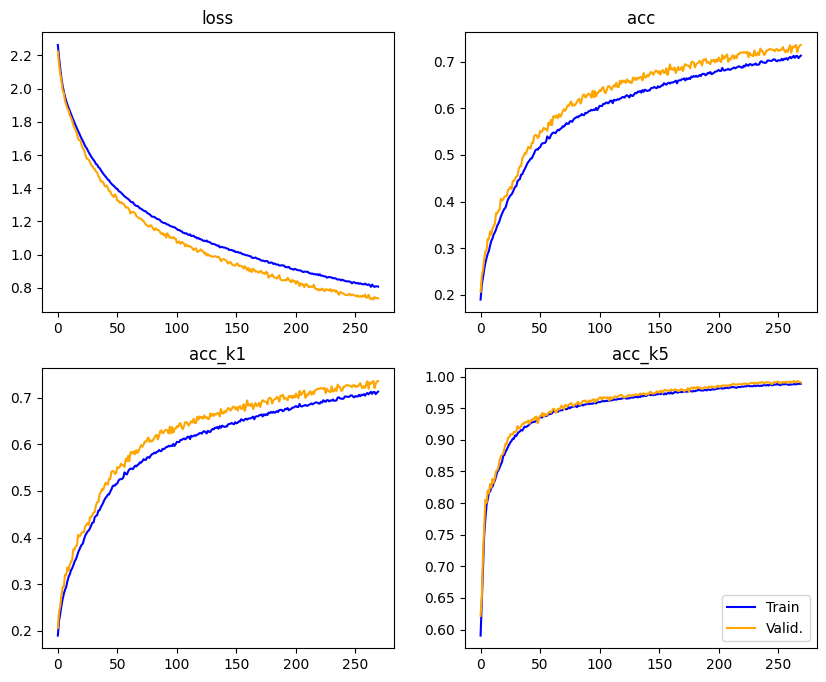

In [89]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
valores_interesse = ['loss','acc','acc_k1','acc_k5']

ax = ax.flatten()

for i, value in enumerate(valores_interesse):
    ax[i].title.set_text(value)
    ax[i].plot(train_result_cnn[value], c="blue", label="Train")
    ax[i].plot(valid_result_cnn[value], c="orange", label="Valid.")
plt.legend()

  - Através das curvas é possível concluir que os valores de acurácia tendem a crescer bem sem aparesentar overfitting.
  - Uma diferença do TOP-1 para o TOP-5 é que, já nas primeiras épocas o TOP-5 tem um pico de acurária muito elevado já chegando em valores satisfatórios, sendo assim, se essa fosse a principal forma de análise não seriam necessárias tantas épocas para atingir um bom resultado

### Acurácia, Recall e Precision em Top-1 e Top-5

Top-1 e Top-5 são diferentes formas de analisar os resultados obtidos pelo modelo:
  - Top-1 accuracy, por exemplo, é a acurácia convencional utilizada. O modelo vai considerar como resposta correta somente a classe que apresentou uma maior probabilidade de ser correta;
  - Top-5 accuracy, diferentemente do top-1, leva em consideração as 5 classes que apresentaram maior probabilidade de ser a correta. Significa que qualquer uma das 5 maiores probabilidades deve estar de acordo com a resposta correta para que seja aceito.
- Para obter os parâmetros de precisão e de recall é preciso saber quals os valores de previsões para o modelo na etapa de teste
- Será criado um código que analisa, para o modelo, em caso de top-1 e top-5 quantas previsões estavam corretas, quantas estavam erradas e quais são elas;

In [90]:
#O código abaixo apresenta a criação de dicionários para armazenar os valores
#que são referentes a acertos e erros das análises top-1 e top-5

In [91]:
prediction_top1 = {'target': [],'prediction': [],}
prediction_top5 = {'target': [],'prediction': [],}

correct_pred_top1 = {'images': [],'target': [],'prediction': [],}
correct_pred_top5 = {'images': [],'target': [],'prediction': [],}

error_pred_top1 = {'images': [],'target': [],'prediction': [],}
error_pred_top5 = {'images': [],'target': [],'prediction': [],}

pred_top1_global_metrics = {'TP': 0, 'FN': 0, 'FP': 0}
pred_top5_global_metrics = {'TP': 0, 'FN': 0, 'FP': 0}

pred_top1_class_metrics = {0: {'TP': 0, 'FN': 0, 'FP': 0},
                          1: {'TP': 0, 'FN': 0, 'FP': 0},
                          2: {'TP': 0, 'FN': 0, 'FP': 0},
                          3: {'TP': 0, 'FN': 0, 'FP': 0},
                          4: {'TP': 0, 'FN': 0, 'FP': 0},
                          5: {'TP': 0, 'FN': 0, 'FP': 0},
                          6: {'TP': 0, 'FN': 0, 'FP': 0},
                          7: {'TP': 0, 'FN': 0, 'FP': 0},
                          8: {'TP': 0, 'FN': 0, 'FP': 0},
                          9: {'TP': 0, 'FN': 0, 'FP': 0},
                          }

pred_top5_class_metrics = {0: {'TP': 0, 'FN': 0, 'FP': 0},
                          1: {'TP': 0, 'FN': 0, 'FP': 0},
                          2: {'TP': 0, 'FN': 0, 'FP': 0},
                          3: {'TP': 0, 'FN': 0, 'FP': 0},
                          4: {'TP': 0, 'FN': 0, 'FP': 0},
                          5: {'TP': 0, 'FN': 0, 'FP': 0},
                          6: {'TP': 0, 'FN': 0, 'FP': 0},
                          7: {'TP': 0, 'FN': 0, 'FP': 0},
                          8: {'TP': 0, 'FN': 0, 'FP': 0},
                          9: {'TP': 0, 'FN': 0, 'FP': 0},
                          }

In [92]:
def add_correct_incorrect_value(dict_interest,image,label,prediction):
    dict_interest['images'].append(image)
    dict_interest['target'].append(label)
    dict_interest['prediction'].append(prediction)
    return dict_interest

In [93]:
predictions_top_1_label = []
predictions_top_5_binary = []
true_labels = []
true_labels_top_5 = []


dataloader_test_final = data.DataLoader(
    ds_test,
    batch_size=1,
    shuffle=False,
    pin_memory=True, #Visa acelerar a memória do processo
    drop_last=False, #Permite que o último batch tenha tamanho menor que os outros
)

for test_data, label in tqdm(dataloader_test_final):
  test_data = test_data.to(device)
  print(f'Qnt de imagens no teste: {test_data.shape}')
  label = label.item()
  true_labels.append(label)

  image = test_data.squeeze(0).permute(1, 2, 0).cpu()

  pred = model_cnn(test_data).cpu()

  predictions = nn.functional.softmax(pred, dim=-1)

  pred_top1 = predictions.argmax(dim=-1).item() #pega o maior valor da previsão para top-1
  predictions_top_1_label.append(pred_top1)

  pred_top5, pred_top5_indices = predictions.topk(5, dim=-1) #vai pegar os 5 maiores valores para top-5
  pred_top5_indices_list = pred_top5_indices.tolist()[0]

#no caso abaixo, vai ser transformado o top-5 em classe binária para cálculos futuros
#caso ele acerte a classe, será considerado 1, caso não, 0
  if label in pred_top5_indices_list:
    predictions_top_5_binary.append(1)
    true_labels_top_5.append(1)
  else:
    predictions_top_5_binary.append(0)
    true_labels_top_5.append(1)

  prediction_top1['target'].append(label)
  prediction_top5['target'].append(label)
  prediction_top1['prediction'].append(pred_top1)
  prediction_top5['prediction'].append(pred_top5_indices_list)

  if pred_top1 != label: #caso não tenha previsto correto
    error_pred_top1 = add_correct_incorrect_value(error_pred_top1,image,label,pred_top1) #adiciona valores ao dicionário

    pred_top1_global_metrics['FN'] += 1
    pred_top1_class_metrics[label]['FN'] += 1 #adiciona 1 valor para aquela label como FN

    pred_top1_global_metrics['FP'] += 1
    pred_top1_class_metrics[pred_top1]['FP'] += 1 #adiciona 1 valor para aquela previsão como FP
  else:
    correct_pred_top1 = add_correct_incorrect_value(correct_pred_top1,image,label,pred_top1)

    pred_top1_global_metrics['TP'] += 1
    pred_top1_class_metrics[label]['TP'] += 1

  if label not in pred_top5_indices_list:
    error_pred_top5 = add_correct_incorrect_value(error_pred_top5,image,label,pred_top5_indices_list)

    pred_top1_global_metrics['FN'] += 1*len(pred_top5_indices_list)
    pred_top5_class_metrics[label]['FN'] += 1*len(pred_top5_indices_list)

    for false_prediction in pred_top5_indices_list:
      pred_top1_global_metrics['FP'] += 1
      pred_top5_class_metrics[false_prediction]['FP'] += 1
  else:
    correct_pred_top5 = add_correct_incorrect_value(correct_pred_top5,image,label,pred_top5_indices_list)

    for correct_pred in pred_top5_indices_list:
      pred_top5_global_metrics['TP'] += 1
      pred_top5_class_metrics[correct_pred]['TP'] += 1

  0%|          | 7/2700 [00:00<00:38, 69.61it/s]

Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de image

  5%|▌         | 140/2700 [00:00<00:06, 402.53it/s]

Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de image

  8%|▊         | 226/2700 [00:00<00:05, 417.94it/s]

...

Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de image

 96%|█████████▌| 2580/2700 [00:05<00:00, 501.32it/s]

Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de image

100%|██████████| 2700/2700 [00:05<00:00, 492.45it/s]

Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de imagens no teste: torch.Size([1, 3, 64, 64])
Qnt de image

In [94]:
classification_report_top1 = classification_report(true_labels, predictions_top_1_label)
classification_report_top5 = classification_report(true_labels_top_5, predictions_top_5_binary)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.



- O classification report para o top-5 vai levar em consideração uma classificação binária, por exemplo, se o target estiver dentre as 5 imagens previstas, vai ser considerado que ele acertou a classe, caso contráio, vai considerar que foi errada.

In [95]:
print(classification_report_top1)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       300
           1       0.79      0.83      0.81       300
           2       0.65      0.59      0.62       300
           3       0.53      0.37      0.43       250
           4       0.84      0.91      0.87       250
           5       0.62      0.80      0.70       200
           6       0.62      0.62      0.62       250
           7       0.77      0.90      0.83       300
           8       0.67      0.64      0.65       250
           9       0.84      0.74      0.79       300

    accuracy                           0.73      2700
   macro avg       0.71      0.72      0.71      2700
weighted avg       0.72      0.73      0.72      2700



In [96]:
print(classification_report_top5)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      1.00      2700

    accuracy                           0.99      2700
   macro avg       0.50      0.50      0.50      2700
weighted avg       1.00      0.99      1.00      2700



In [97]:
def calc_metrics(dict_prec,type_calc,index=None):
  if index is None: #pega somente os valores gerais, sem levar as classes em consideração
    value = dict_prec['TP'] + dict_prec[type_calc] #valor da divisão, ou FP ou FN
    if value != 0: #Verifica que o valor do divisor não é zero
      return dict_prec['TP']/value
    else:
      return 0
  else:
    dict_precision = {}
    for key in dict_prec.keys(): #vai calcular cada valor pela sua classe
      divisor = dict_prec[key]['TP'] + dict_prec[key][type_calc]
      if divisor != 0:
        dict_precision[key] = dict_prec[key]['TP']/divisor
      else:
        dict_precision[key] = 0
    return dict_precision

total_predictions = len(prediction_top1['target'])

correct_top_1_pred = len(correct_pred_top1['prediction'])
correct_top_5_pred = len(correct_pred_top5['prediction'])

error_top_1_pred = len(error_pred_top1['prediction'])
error_top_5_pred = len(error_pred_top5['prediction'])

acuracia_top_1 = correct_top_1_pred/total_predictions
acuracia_top_5 = correct_top_5_pred/total_predictions

precision_top1 = calc_metrics(pred_top1_global_metrics,'FP')
precision_top5 = calc_metrics(pred_top5_global_metrics,'FP')

precision_top1_class = calc_metrics(pred_top1_class_metrics,'FP','yes')
precision_top5_class = calc_metrics(pred_top5_class_metrics,'FP','yes')

recall_top1 = calc_metrics(pred_top1_global_metrics,'FN')
recall_top5 = calc_metrics(pred_top5_global_metrics,'FN')

recall_top1_class = calc_metrics(pred_top1_class_metrics,'FN','yes')
recall_top5_class = calc_metrics(pred_top5_class_metrics,'FN','yes')

In [98]:
def print_classes(dict_wanted1,dict_wanted2,type_element1,type_element2):
  print(type_element1," "*16,type_element2)
  for key in dict_wanted1.keys():
    print_1 = f'  - Classe {key} - {dict_wanted1[key]:.2f}'
    for key2 in dict_wanted2.keys():
      print_2 = f'; Classe {key} - {dict_wanted2[key2]:.2f}'
    print(print_1,print_2)

print(f'Quantidade de elementos corretos de {total_predictions}')
print(f'Top-1: {correct_top_1_pred}')
print(f'Top-5: {correct_top_5_pred}')

print(f'\nQuantidade de elementos errados de {total_predictions}')
print(f'Top-1: {error_top_1_pred}')
print(f'Top-5: {error_top_5_pred}')

print(f'\nAcurácia Total: ')
print(f'Top-1: {acuracia_top_1:.2f}')
print(f'Top-5: {acuracia_top_5:.2f}')

print(f'\nPrecision Total: ')
print(f'Top-1: {precision_top1:.2f}')
print(f'Top-5: {precision_top5:.2f}')

print(f'\nPrecision por Classe: ')
print_classes(precision_top1_class,precision_top5_class,'Top-1:','Top-5:')

print(f'\nRecall Total: ')
print(f'Top-1: {recall_top1:.2f}')
print(f'Top-5: {recall_top5:.2f}')

print(f'\nRecall por Classe: ')
print_classes(recall_top1_class,recall_top5_class,'Top-1:','Top-5:')

Quantidade de elementos corretos de 2700
Top-1: 1959
Top-5: 2676

Quantidade de elementos errados de 2700
Top-1: 741
Top-5: 24

Acurácia Total: 
Top-1: 0.73
Top-5: 0.99

Precision Total: 
Top-1: 0.69
Top-5: 1.00

Precision por Classe: 
Top-1:                  Top-5:
  - Classe 0 - 0.81 ; Classe 0 - 0.99
  - Classe 1 - 0.79 ; Classe 1 - 0.99
  - Classe 2 - 0.65 ; Classe 2 - 0.99
  - Classe 3 - 0.53 ; Classe 3 - 0.99
  - Classe 4 - 0.84 ; Classe 4 - 0.99
  - Classe 5 - 0.62 ; Classe 5 - 0.99
  - Classe 6 - 0.62 ; Classe 6 - 0.99
  - Classe 7 - 0.77 ; Classe 7 - 0.99
  - Classe 8 - 0.67 ; Classe 8 - 0.99
  - Classe 9 - 0.84 ; Classe 9 - 0.99

Recall Total: 
Top-1: 0.69
Top-5: 1.00

Recall por Classe: 
Top-1:                  Top-5:
  - Classe 0 - 0.82 ; Classe 0 - 0.99
  - Classe 1 - 0.83 ; Classe 1 - 0.99
  - Classe 2 - 0.59 ; Classe 2 - 0.99
  - Classe 3 - 0.37 ; Classe 3 - 0.99
  - Classe 4 - 0.91 ; Classe 4 - 0.99
  - Classe 5 - 0.80 ; Classe 5 - 0.99
  - Classe 6 - 0.62 ; Classe 6 - 

- Como foi comentado anteriormente, com a obtenção dos gráficos de perda e acurácia ao longo do tempo, a acurácia top-5, se levada em consideração, apresenta uma acurácia próxima de 100%, significando que, na maioria dos casos a classe verdadeira, no momento da classificação, estará entre as 5 com maiores probabilidades de acontecer.

### Matriz de Confusão para Análise dos resultados

A matriz de confusão será apresentada somente para o TOP-1, analisando somente aqueles casos em que o resultado que teve maior probabilidade de previsão foi equivalente ao valor TARGET real

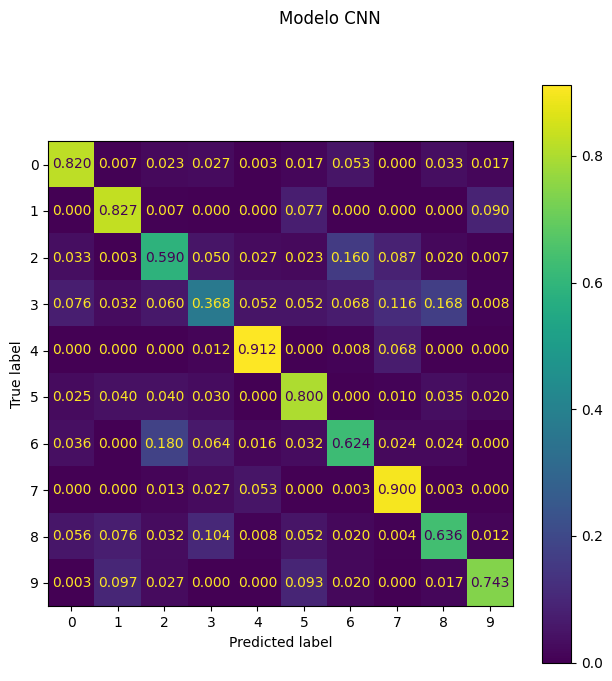

In [99]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
plt.suptitle("Modelo CNN")
ax.grid(False)
cmd = ConfusionMatrixDisplay.from_predictions(
    prediction_top1["target"],
    prediction_top1["prediction"],
    normalize='true',
    values_format='.3f',
    ax=ax
)

A matriz de confusão apresenta True Label X Predicted Label.
  - Através dela é possível ver como se deu a distribuição das classificações previstas melo modelo de acordo com as diferentes classes
  - É possível ver que a classe que apresentou mais dificuldade para ser classificada foi a classe 3, sendo majoritariamente confundida com as classes 7 e 8
  - A segunda classe que apresentou uma maior dificuldade para classificação foi a classe 2, confundida majoritariamente com a classe 6 que também obteve resultados que a confundiam com a classe 2

### Visualização de previsões corretas e incorretas nos dados de teste

Para a visualização dos dados

In [100]:
interesting_labels = [x for x in range(10)]

- Vão ser escolhidas 10 imagens, dentre as corretas e as erradas, uma para cada um dos verdadeiros targets almejados

In [101]:
#A função de chose_img vai selecionar uma imagem de cada classe para cada um dos tipos
#tanto top-1 como top-5, imagens corretas e erradas
def chose_img(dict_to_chose,dict_to_add):
  set_label = set() #vai forçar para que exista somente uma classe selecionada
  for i in range(len(dict_to_chose['target'])):
    if dict_to_chose['target'][i] not in set_label:
      set_label.add(dict_to_chose['target'][i])
      dict_to_add['images'].append(dict_to_chose['images'][i])
      dict_to_add['target'].append(dict_to_chose['target'][i])
      dict_to_add['prediction'].append(dict_to_chose['prediction'][i])
    if len(set_label) == 10:
      break
  return  dict_to_add

chosen_correct_img_top1 = {'images': [],'target': [],'prediction': [],}
chosen_correct_img_top1 = chose_img(correct_pred_top1,chosen_correct_img_top1)

chosen_error_img_top1 = {'images': [],'target': [],'prediction': [],}
chosen_error_img_top1 = chose_img(error_pred_top1,chosen_error_img_top1)

chosen_correct_img_top5 = {'images': [],'target': [],'prediction': [],}
chosen_correct_img_top5 = chose_img(correct_pred_top5,chosen_correct_img_top5)

chosen_error_img_top5 = {'images': [],'target': [],'prediction': [],}
chosen_error_img_top5 = chose_img(error_pred_top5,chosen_error_img_top5)

In [102]:
print(f"{len(chosen_correct_img_top1['target'])=}")
print(f"{len(chosen_error_img_top1['target'])=}")
print(f"{len(chosen_correct_img_top5['target'])=}")
print(f"{len(chosen_error_img_top5['target'])=}")

len(chosen_correct_img_top1['target'])=10
len(chosen_error_img_top1['target'])=10
len(chosen_correct_img_top5['target'])=10
len(chosen_error_img_top5['target'])=7


In [103]:
def print_img(dic_chosen):
  qnt_colunas = len(dic_chosen['images'])
  fig, axes = plt.subplots(1, qnt_colunas, figsize=(qnt_colunas * 3, 3))


  if qnt_colunas == 1:
      axes = [axes]

  for i, ax in enumerate(axes):
      img = dic_chosen['images'][i]
      ax.imshow(img)
      target = dic_chosen['target'][i]
      prediction = dic_chosen['prediction'][i]

      for key, value in label_map.items(): #vai correlacionar o número da classe com seu nome
        if value == prediction and type(prediction) == int:
          prediction_name = key
        if value == target:
            target_name = key

      if type(prediction) == int: #vai fazer com que, no caso de top-5, não seja impressa a classe das 5 previsões
        if target_name == prediction_name:
          title = f"T: {dic_chosen['target'][i]}\nP: {prediction}({target_name})"
        else:
          title = f"T: {dic_chosen['target'][i]}({target_name})\nP: {prediction}({prediction_name})"
      else:
        title =  f"T: {dic_chosen['target'][i]}({target_name})\nP: {prediction}"
      ax.set_title(title,fontsize=13)
      ax.axis("off")

  plt.tight_layout()
  plt.show()

Imagens Corretas: TOP-1


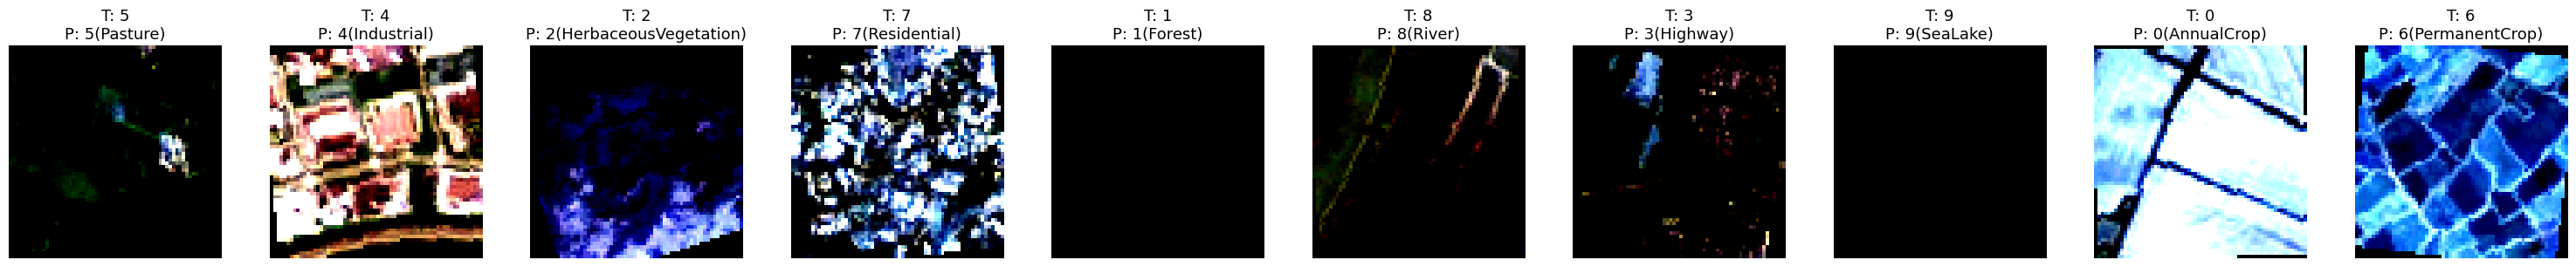

In [104]:
print('Imagens Corretas: TOP-1')
print_img(chosen_correct_img_top1)

Imagens Erradas: TOP-1


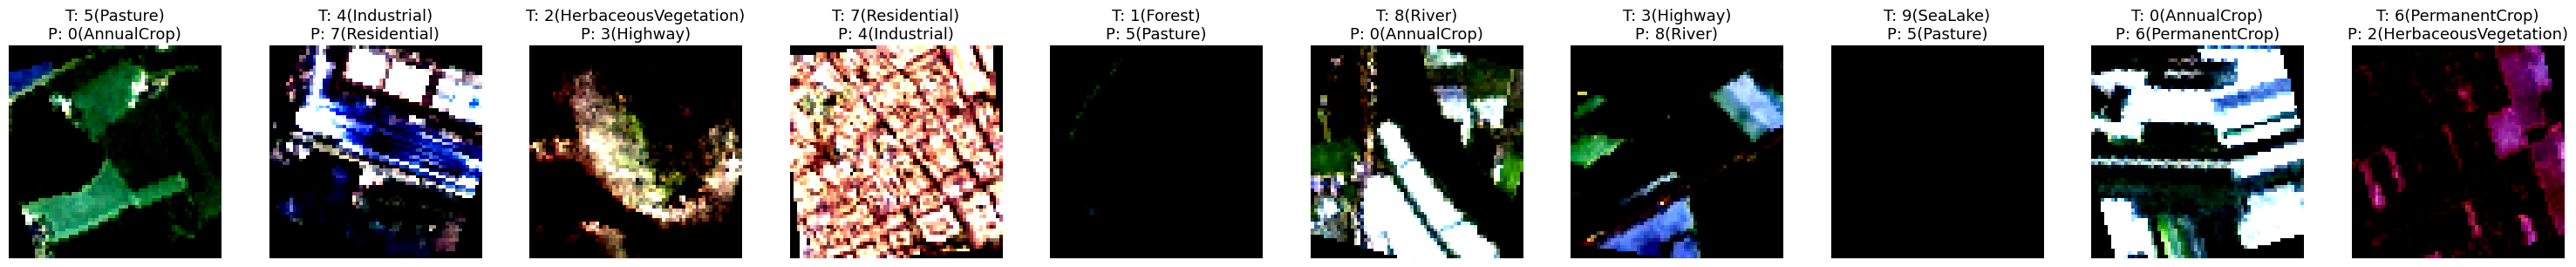

In [105]:
print('Imagens Erradas: TOP-1')
print_img(chosen_error_img_top1)

Imagens Corretas: TOP-5


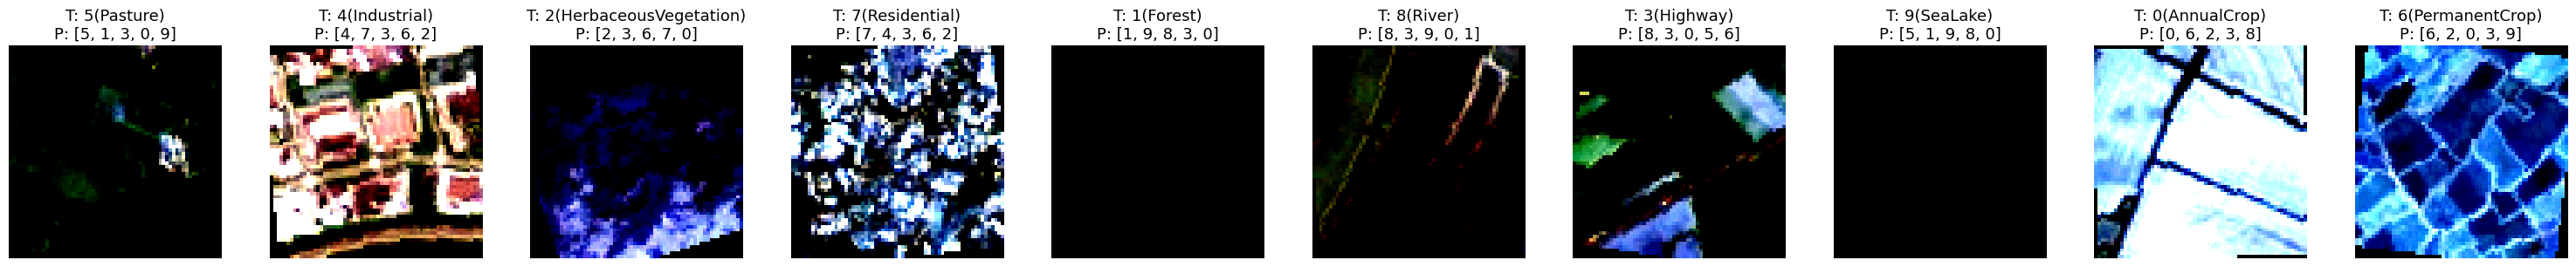

In [106]:
print('Imagens Corretas: TOP-5')
print_img(chosen_correct_img_top5)

Imagens Erradas: TOP-5


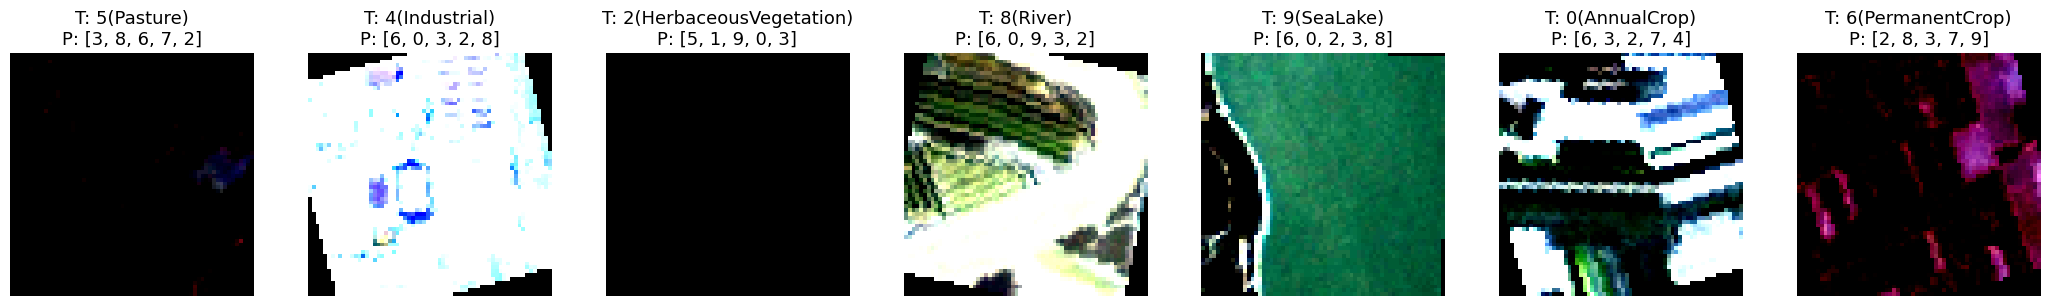

In [107]:
print('Imagens Erradas: TOP-5')
print_img(chosen_error_img_top5)

- Observa-se que as imagens que foram classificadas incorretamente ou não possuiam uma boa delimitação na imagem, ou apresentavam algumas características que pareciam demais com algumas outras, gerando assim a confusão dentre elas.
- Nas imagens, a letra `P` indica a label prevista, enquanto a letra `T` a label verdadeira

##Conclusão

- Pode-se concluir que o projeto apresentou bons resultados para a classificação das imagens, com uma acurácia acima de `70%`
- Para este modelo, pode-se concluir que a diferença inicial de quantidade de amostras por classe não apresentou interferência na classificação, isto por que  a classe com menor quantidade de amostras, classe 5 (2000 amostras), apresentou bons resultados quando olhamos a matriz de confusão.
  - Entretando, pode ser que caso houvessem mais amostras o programa poderia ter trabalhado melhor em algumas classes que não apresentaram bons resultados, como no caso da classe 3 que apresentava 2500 amostras, comparando com outras que apresentavam 3000.
- Como mencionamento no início, poderia haver uma confusão entre as classes 3 e 8 (Highway e River) visto que, visualmente, algumas das rodovias e dos lagos apresentavam características parecidas. Esta ideia inicial foi corroborada pela matriz de confusão
- No geral, o modelo apresentou resultados satisfatórios para a classificação de imagens. Entretando, caso o objetivo seja focar em algumas classes especificas, como por exemplo a 3, talvez seja melhor testar outra arquitetura visto que o modelo não atendeu essa classe bem.
- Por fim, caso a ideia seja utilizar o modelo para um tipo de classificação mais geral, que considerasse o TOP-5 ele seria de ótima aplicabilidade visto que, para este tipo de análise, a acurária atingiui valores próximos de `100%`.
- O projeto foi importante principalmente para aprofundar o conhecimento no quesito de classificação de imagens e implementação de modelos manualmente, desenvolvendo mais a fundo o conhecimento de implementação de camadas e de hiperparâmetros.

##Referências Utilizadas

- Adicionar um arquivo a um repositório em GitHGub: [Link](https://docs.github.com/pt/repositories/working-with-files/managing-files/adding-a-file-to-a-repository)
- Como normalizar conjunto de dados de imagem usando PyTorch [Link](https://saturncloud.io/blog/how-to-normalize-image-dataset-using-pytorch/)
- Computing Mean & STD in Image Dataset [Link](https://kozodoi.me/blog/20210308/compute-image-stats)
- Convolutional Neural Networks (CNN) with TensorFlow Tutorial [Link](https://www.datacamp.com/tutorial/cnn-tensorflow-python/)
- Download da biblioteca `EuroSat Dataset`: [Link](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset/data)
- Gráficos interativos usando python plotly [Link](https://halisson-gomides.medium.com/construindo-gr%C3%A1ficos-interativos-usando-python-plotly-51d330b1ce9e)
- What is Ground Sampling Distance (GSD) Resolution? [Link](https://skyfi.com/en/blog/interpreting-daytime-resolution)
- What is top-1 and top-5 accuracy? [Link](https://www.kaggle.com/discussions/questions-and-answers/164379)
- Writing CNNs from Scratch in PyTorch [Link](https://www.digitalocean.com/community/tutorials/writing-cnns-from-scratch-in-pytorch)
- Writing Custom Datasets, DataLoaders and Transforms [Link](https://pytorch.org/tutorials/beginner/data_loading_tutorial)
- Precisão, Recall e F1 Score Em Machine Learning [Link](https://mariofilho.com/precisao-recall-e-f1-score-em-machine-learning/#o-que-%C3%A9-precis%C3%A3o)